Importing the Necessary Modules

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import pyplot
import random
import json
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go

Connecting to the Database

In [2]:
db_username_0 = 'simulationuser'
db_password_0 = 'simulations2024'
db_host_0 = 'localhost'
db_port_0 = '5432'
db_name_0 = 'simulations_data'
table_name_0 = 'neutral_ensembles'

In [3]:
connection_string = f"postgresql://{db_username_0}:{db_password_0}@{db_host_0}:{db_port_0}/{db_name_0}"
engine = create_engine(connection_string)
query = f"SELECT * FROM {table_name_0}"
df = pd.read_sql(query, engine)
df = df.iloc[:10000]

The DataFrame

In [4]:
len(df)

10000

Verifying Details

Defining Common Functions

In [5]:
def average_arrays(*arrays):
    if not arrays:
        raise ValueError("No arrays provided for averaging.")
    
    np_arrays = [np.array(arr) for arr in arrays]
    array_lengths = [len(arr) for arr in np_arrays]

    if len(set(array_lengths)) != 1:
        raise ValueError("All input arrays must have the same length.")
    
    average_array = np.mean(np_arrays, axis=0)
    
    return average_array

Composite Analysis of All the Data

In [6]:
average_psi_e = average_arrays(*list(df['psi_e']))
average_b_e = average_arrays(*list(df['b_e']))
average_psi_plus = average_arrays(*list(df['psi_plus']))
average_b_plus = average_arrays(*list(df['b_plus']))
average_U = average_arrays(*list(df['u_list']))
average_R = average_arrays(*list(df['r_list']))
average_k_e_psi_e_list = average_arrays(*list(df['k_e_psi_e_list']))
average_k_e_b_e_list = average_arrays(*list(df['k_e_b_e_list']))
average_k_e_psi_plus_list = average_arrays(*list(df['k_e_psi_plus_list']))
average_k_e_b_plus_list = average_arrays(*list(df['k_e_b_plus_list']))
average_heat_flux_psi_e_b_e_list = average_arrays(*list(df['heat_flux_psi_e_b_e_list']))
average_heat_flux_psi_e_b_plus_list = average_arrays(*list(df['heat_flux_psi_e_b_plus_list']))
average_b_e_psi_plus_list = average_arrays(*list(df['b_e_psi_plus_list']))
average_b_e_b_plus_list = average_arrays(*list(df['b_e_b_plus_list']))
average_psi_plus_b_plus_list = average_arrays(*list(df['psi_plus_b_plus_list']))
average_eta = average_arrays(*list(df['eta_list']))

In [7]:
window_size = 5000
dt = .001
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387

In [9]:
import json
import numpy as np
import pandas as pd
# import plotly.express as px  # (optional; not used below)
import plotly.graph_objects as go
from pathlib import Path

def _ensure_list(x):
    # Convert strings like "[1,2,3]" -> Python lists
    if isinstance(x, str):
        return json.loads(x)
    return x

def to_long_events(
    df,
    dt=0.01,
    stride=10,
    sample_events=None,
    max_points=300_000,
    window_sec=1.0,
    exclude_center_sec=0.0,   # cut out (-exclude_center_sec, +exclude_center_sec)
    window_left_sec=None,     # optional asymmetric outer windows
    window_right_sec=None
):
    """
    df: one row per reversal; columns: psi_e, b_e, psi_plus, b_plus, u_list, (optionally) id
    dt: simulation time step (seconds)
    stride: downsample factor inside each event
    sample_events: randomly sample this many events to keep plots fast (None = use all)
    max_points: hard cap on total rows across events
    window_sec: half-width of the outer window if asymmetric values aren't provided
    exclude_center_sec: half-width of the inner gap to exclude around the reversal (0 = no gap)
    window_left_sec/window_right_sec: optional asymmetric outer half-widths; if None, use window_sec
    """
    if sample_events is not None and len(df) > sample_events:
        df = df.sample(sample_events, random_state=0)

    # Resolve symmetric/asymmetric outer windows
    L = float(window_left_sec if window_left_sec is not None else window_sec)
    R = float(window_right_sec if window_right_sec is not None else window_sec)
    gap = max(0.0, float(exclude_center_sec))

    # If the gap eats the whole window on either side, clamp to keep at least one sample window
    if gap >= max(L, R):
        # nothing would remain; shrink gap slightly
        gap = 0.99 * max(L, R)

    frames, total = [], 0
    left_outer_steps  = int(L / dt)
    right_outer_steps = int(R / dt)
    inner_gap_steps   = int(gap / dt)

    # Ensure we have a stable event id source
    has_id_col = "id" in df.columns

    for i, (_, row) in enumerate(df.iterrows()):
        event_id = int(row["id"]) if has_id_col else int(i)

        psi_e = np.asarray(_ensure_list(row["psi_e"]))
        b_e   = np.asarray(_ensure_list(row["b_e"]))
        psi_p = np.asarray(_ensure_list(row["psi_plus"]))
        b_p   = np.asarray(_ensure_list(row["b_plus"]))
        U     = np.asarray(_ensure_list(row["u_list"]))

        n = len(U)
        if not (len(psi_e)==len(b_e)==len(psi_p)==len(b_p)==n):
            continue

        center = n // 2  # reversal index (assumed midpoint)

        # Compute outer and inner bounds (clamped to [0, n))
        left_start  = max(0, center - left_outer_steps)
        left_end    = max(0, min(n, center - inner_gap_steps))     # stop before the gap
        right_start = min(n, max(0, center + inner_gap_steps))     # start after the gap
        right_end   = min(n, center + right_outer_steps)

        # Build indices on each side, with downsampling stride
        left_idx  = np.arange(left_start, left_end, stride)  if left_end > left_start  else np.array([], dtype=int)
        right_idx = np.arange(right_start, right_end, stride) if right_end > right_start else np.array([], dtype=int)

        # Concatenate. If gap == 0, left_end == center and right_start == center -> continuous window.
        idx = np.concatenate([left_idx, right_idx])
        if idx.size == 0:
            continue

        tau = (idx - center) * dt
        phase = np.where(idx < center, "before", "after")

        sub = pd.DataFrame({
            "event_id": event_id,
            "t_idx": idx,
            "tau": tau,
            "phase": phase.astype(str),
            "psi_e": psi_e[idx],
            "b_e":   b_e[idx],
            "psi_p": psi_p[idx],
            "b_p":   b_p[idx],
            "U":     U[idx],
        })
        frames.append(sub)
        total += len(sub)
        if total >= max_points:
            break

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


# --- Build long table: keep [-2, -0.5] and [0.5, 2]
df_long = to_long_events(
    df,
    dt=0.01,
    stride=1,
    sample_events=10,      # adjust as you like
    max_points=300_000,
    window_sec=5,        # outer half-window
    exclude_center_sec=0 # inner half-gap
)

print(df_long.shape, df_long.columns.tolist())

# --- Plotly 3D scatter for all 6 pairs. Color by tau (or switch to "phase")
pairs = [
    ("psi_e","b_e"),
    ("psi_e","psi_p"),
    ("psi_e","b_p"),
    ("b_e","psi_p"),
    ("b_e","b_p"),
    ("psi_p","b_p"),
]

outdir = Path("plotly_3d_pairs_neutral"); outdir.mkdir(exist_ok=True)

for x, y in pairs:
    fig = go.Figure()

    for eid, sub in df_long.groupby("event_id"):
        sub = sub.sort_values("tau")  # order points in time
        fig.add_trace(go.Scatter3d(
            x=sub[x], y=sub[y], z=sub["U"],
            mode="lines+markers",
            line=dict(width=2),
            marker=dict(size=3, color=sub["tau"], colorscale="Viridis", showscale=False),
            name=f"event {eid}"
        ))

    fig.update_layout(
        title=f"U vs {x}, {y} — trajectory lines",
        scene=dict(xaxis_title=x, yaxis_title=y, zaxis_title="U"),
        template="simple_white",
        margin=dict(l=0, r=0, t=40, b=0)
    )

    html_path = outdir / f"U_vs_{x}_{y}_lines.html"
    fig.write_html(str(html_path))
    print(f"Saved {html_path}")


(10000, 9) ['event_id', 't_idx', 'tau', 'phase', 'psi_e', 'b_e', 'psi_p', 'b_p', 'U']
Saved plotly_3d_pairs_neutral/U_vs_psi_e_b_e_lines.html
Saved plotly_3d_pairs_neutral/U_vs_psi_e_psi_p_lines.html
Saved plotly_3d_pairs_neutral/U_vs_psi_e_b_p_lines.html
Saved plotly_3d_pairs_neutral/U_vs_b_e_psi_p_lines.html
Saved plotly_3d_pairs_neutral/U_vs_b_e_b_p_lines.html
Saved plotly_3d_pairs_neutral/U_vs_psi_p_b_p_lines.html


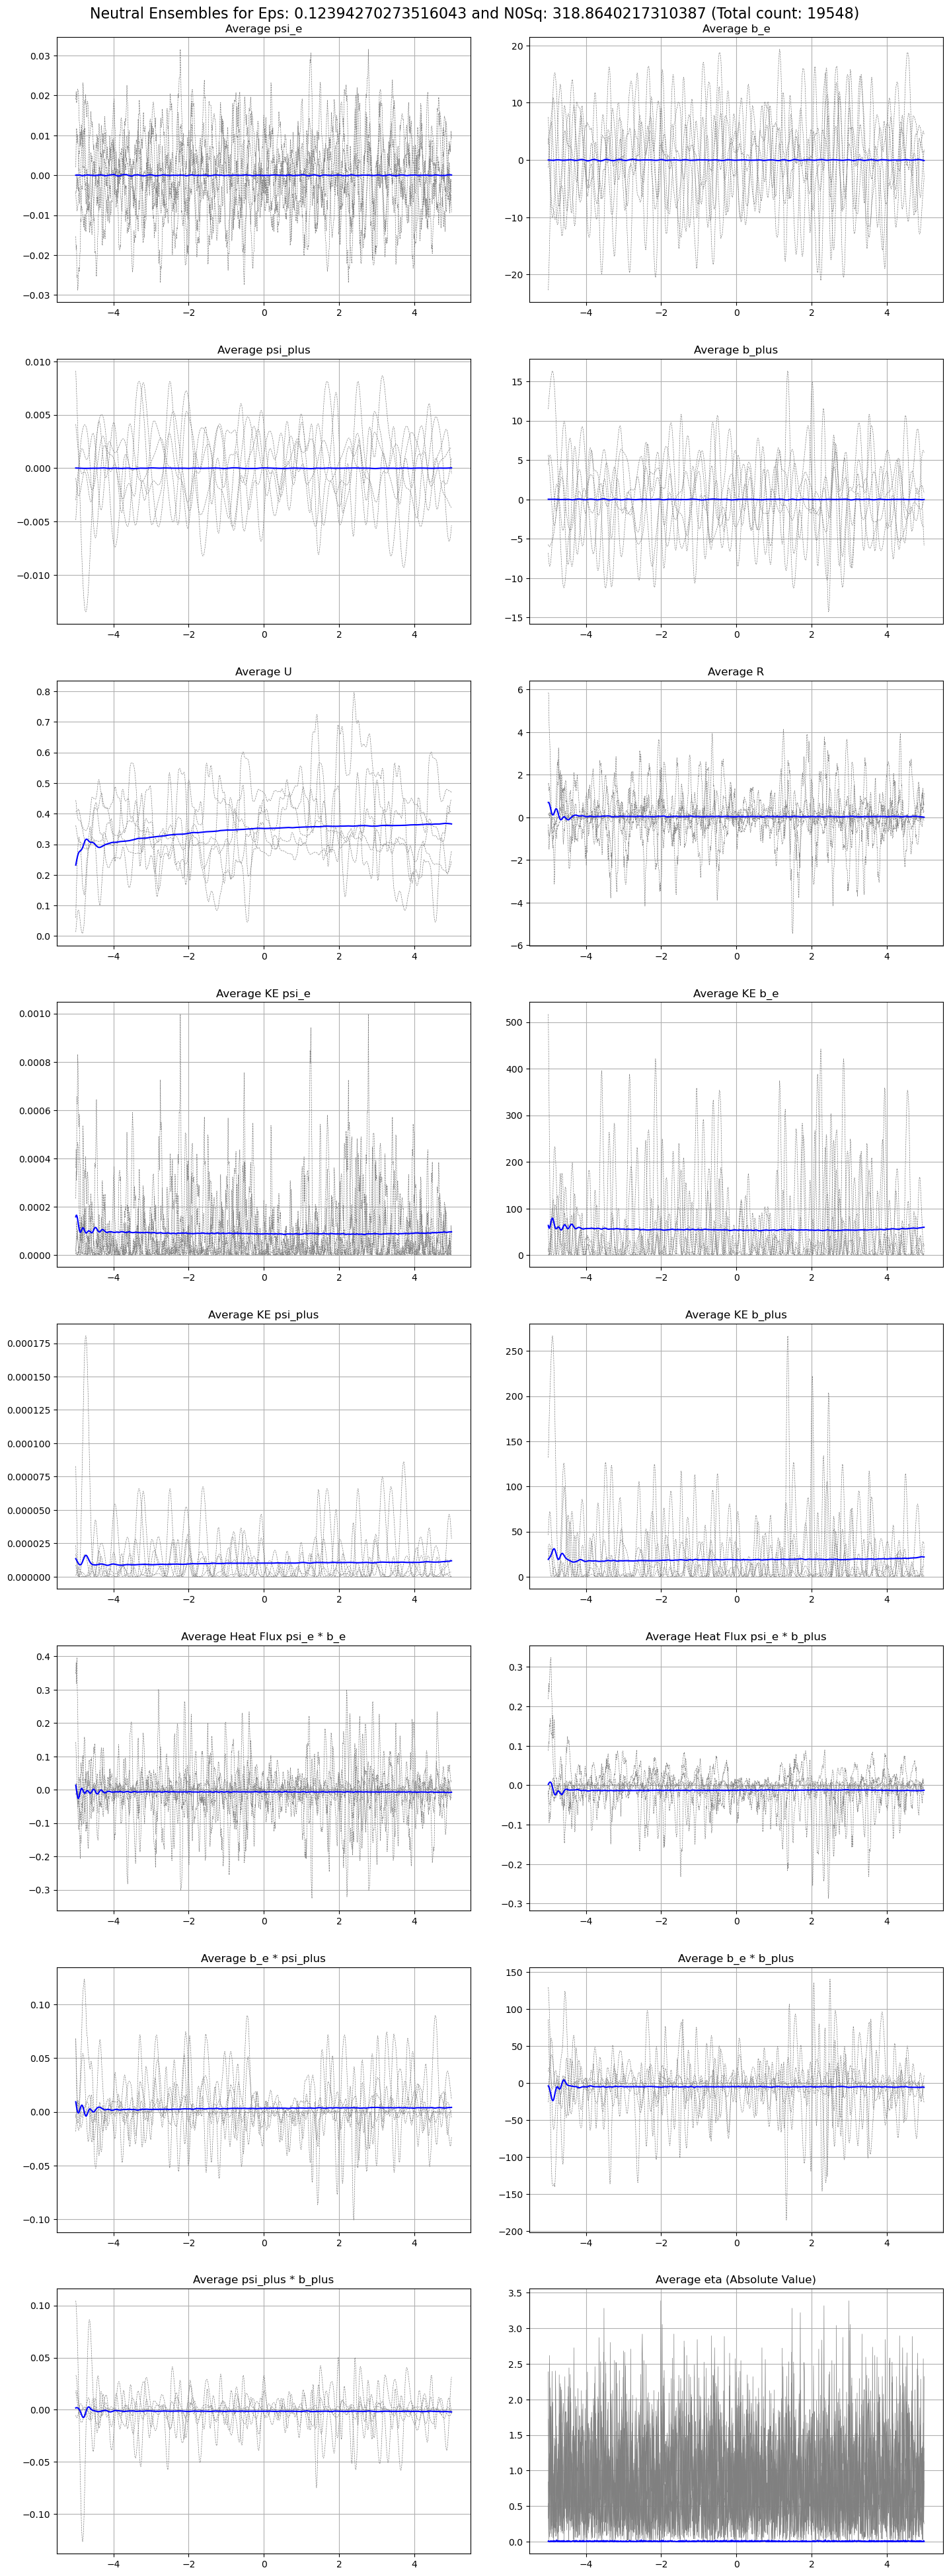

In [11]:
time_array = np.arange(-window_size/10, window_size/10) * dt * 10

fig, axs = plt.subplots(8, 2, figsize=(15, 40))

for i in range(5):
    axs[0, 0].plot(time_array, df['psi_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 0].plot(time_array, average_psi_e, label='Average', linewidth=1.5, color='blue')
axs[0, 0].set_title(f'Average psi_e')
axs[0, 0].grid()


for i in range(5):
    axs[0, 1].plot(time_array, df['b_e'][i], linewidth=0.5, linestyle='--', color='gray')
axs[0, 1].plot(time_array, average_b_e, label='Average', linewidth=1.5, color='blue')
axs[0, 1].set_title(f'Average b_e')
axs[0, 1].grid()

for i in range(5):
    axs[1, 0].plot(time_array, df['psi_plus'][i],linewidth=0.5, linestyle='--', color='gray') 
axs[1, 0].plot(time_array, average_psi_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 0].set_title(f'Average psi_plus')
axs[1, 0].grid()

for i in range(5):
    axs[1, 1].plot(time_array, df['b_plus'][i], linewidth=0.5, linestyle='--', color='gray')
axs[1, 1].plot(time_array, average_b_plus, label='Average', linewidth=1.5, color='blue')
axs[1, 1].set_title(f'Average b_plus')
axs[1, 1].grid()

for i in range(5):
    axs[2, 0].plot(time_array, df['u_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 0].plot(time_array, average_U, label='Average', linewidth=1.5, color='blue')
axs[2, 0].set_title(f'Average U')
axs[2, 0].grid()

for i in range(5):
    axs[2, 1].plot(time_array, df['r_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[2, 1].plot(time_array, average_R, label='Average', linewidth=1.5, color='blue')
axs[2, 1].set_title(f'Average R')
axs[2, 1].grid()

for i in range(5):
    axs[3, 0].plot(time_array, df['k_e_psi_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 0].plot(time_array, average_k_e_psi_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 0].set_title(f'Average KE psi_e')
axs[3, 0].grid()

for i in range(5):
    axs[3, 1].plot(time_array, df['k_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[3, 1].plot(time_array, average_k_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[3, 1].set_title(f'Average KE b_e')
axs[3, 1].grid()

for i in range(5):
    axs[4, 0].plot(time_array, df['k_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 0].plot(time_array, average_k_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 0].set_title(f'Average KE psi_plus')
axs[4, 0].grid()

for i in range(5):
    axs[4, 1].plot(time_array, df['k_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[4, 1].plot(time_array, average_k_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[4, 1].set_title(f'Average KE b_plus')
axs[4, 1].grid()

for i in range(5):
    axs[5, 0].plot(time_array, df['heat_flux_psi_e_b_e_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 0].plot(time_array, average_heat_flux_psi_e_b_e_list, label='Average', linewidth=1.5, color='blue')
axs[5, 0].set_title(f'Average Heat Flux psi_e * b_e')
axs[5, 0].grid()

for i in range(5):
    axs[5, 1].plot(time_array, df['heat_flux_psi_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[5, 1].plot(time_array, average_heat_flux_psi_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[5, 1].set_title(f'Average Heat Flux psi_e * b_plus')
axs[5, 1].grid()

for i in range(5):
    axs[6, 0].plot(time_array, df['b_e_psi_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 0].plot(time_array, average_b_e_psi_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 0].set_title(f'Average b_e * psi_plus')
axs[6, 0].grid()

for i in range(5):
    axs[6, 1].plot(time_array, df['b_e_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[6, 1].plot(time_array, average_b_e_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[6, 1].set_title(f'Average b_e * b_plus')
axs[6, 1].grid()

for i in range(5):
    axs[7, 0].plot(time_array, df['psi_plus_b_plus_list'][i], linewidth=0.5, linestyle='--', color='gray')
axs[7, 0].plot(time_array, average_psi_plus_b_plus_list, label='Average', linewidth=1.5, color='blue')
axs[7, 0].set_title(f'Average psi_plus * b_plus')
axs[7, 0].grid()

average_eta = [[abs(i) for i in sublist] for sublist in average_eta]

for i in range(5): #Check if the average eta is the same using randn 
    axs[7, 1].plot(time_array, [abs(i[0]) for i in df['eta_list'][i]], linewidth=0.5, linestyle='-', label=f'eta_list {i}', color = 'gray')
axs[7, 1].plot(time_array, [abs(i[0]) for i in average_eta], label='Average', linewidth=1.5, color='blue')
axs[7, 1].set_title('Average eta (Absolute Value)')
axs[7, 1].grid()


plt.suptitle(f'Neutral Ensembles for Eps: {epsilon} and N0Sq: {N_0_squared} (Total count: {len(list(df['b_e']))})', fontsize=16)
plt.subplots_adjust(wspace=0.3, hspace=0.3, top=1.85)

plt.tight_layout(pad = 3)

plt.show()

In [12]:
#<U*k_e_psi_e>
temp_u_list = df['u_list'].apply(np.array)
temp_k_e_psi_e_list = df['k_e_psi_e_list'].apply(np.array)
UK_e_psi_e = np.array([i * j for i, j in zip(temp_u_list, temp_k_e_psi_e_list)])
average_UK_e_psi_e = average_arrays(*list(UK_e_psi_e))

In [13]:
#<U*k_e_psi_plus>
temp_u_list = df['u_list'].apply(np.array)
temp_k_e_psi_plus_list = df['k_e_psi_plus_list'].apply(np.array)
UK_e_psi_plus = np.array([i * j for i, j in zip(temp_u_list, temp_k_e_psi_plus_list)])
average_UK_e_psi_plus = average_arrays(*list(UK_e_psi_plus))

In [14]:
epsilon = 0.12394270273516043
N_0_squared = 318.8640217310387
r_m = 0.1
k = 2 * np.pi * 6
m = 2 * np.pi * 3
m_u = 2 * np.pi * 7
dt = 0.001
total_time = 200
k_e_square = k**2 + m**2
k_plus_square = k**2 + (m + m_u)**2

In [15]:
p = k / k_e_square
q = -k / k_plus_square
r = k * N_0_squared
s = -k * (k_plus_square - m_u**2) / (2*k_e_square)
t = -k * (m_u**2 - k_e_square) / (2 * k_plus_square)
v = k / 2

In [16]:
bigW = np.array([[-1, p, 0, 0], [-r, -1, 0, 0], [0, 0, -1, q], [0, 0, r, -1]])
bigL = np.array([[0, 0, s, 0], [0, 0, 0, v], [t, 0, 0, 0], [0, -v, 0, 0]])
bigQ = np.array([[8/k_e_square, 0, 0, 0],[0, 0, 0, 0],[0, 0, 0, 0],[0, 0, 0, 0]])

In [17]:
def create_C_matrix(row):
    length = len(row['k_e_psi_e_list'])  
    matrices = []
    
    for i in range(length):
        ke_psi_e = row['k_e_psi_e_list'][i]
        ke_b_e = row['k_e_b_e_list'][i]
        ke_psi_plus = row['k_e_psi_plus_list'][i]
        ke_b_plus = row['k_e_b_plus_list'][i]
        
        heat_flux_psi_e_b_e = row['heat_flux_psi_e_b_e_list'][i]
        heat_flux_psi_e_b_plus = row['heat_flux_psi_e_b_plus_list'][i]
        b_e_psi_plus = row['b_e_psi_plus_list'][i]
        b_e_b_plus = row['b_e_b_plus_list'][i]
        
        psi_plus_b_plus = row['psi_plus_b_plus_list'][i]
        psi_e_psi_plus = row['r_list'][i] 

        C_matrix = np.array([
            [ke_psi_e, heat_flux_psi_e_b_e, psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), heat_flux_psi_e_b_plus],
            [heat_flux_psi_e_b_e, ke_b_e, b_e_psi_plus, b_e_b_plus],
            [psi_e_psi_plus/(0.25 * k * (k_plus_square - k_e_square)), b_e_psi_plus, ke_psi_plus, psi_plus_b_plus],
            [heat_flux_psi_e_b_plus, b_e_b_plus, psi_plus_b_plus, ke_b_plus]
        ])
        
        matrices.append(C_matrix)

    return matrices 

In [18]:
df['C_Matrix'] = df.apply(create_C_matrix, axis = 1)
df.head()

,id,eps,n_0_squared,psi_e,b_e,psi_plus,b_plus,u_list,r_list,k_e_psi_e_list,k_e_b_e_list,k_e_psi_plus_list,k_e_b_plus_list,heat_flux_psi_e_b_e_list,heat_flux_psi_e_b_plus_list,b_e_psi_plus_list,b_e_b_plus_list,psi_plus_b_plus_list,eta_list,C_Matrix
0,1,0.123943,318.864022,"[0.01901241359915969, 0.02094565213828948, 0.0...","[7.504182919637149, 5.242168510692357, 3.25751...","[0.009100088897106815, 0.008170502473702008, 0...","[11.483256211928511, 12.305335670598128, 12.99...","[0.059856969573462815, 0.11815828270323876, 0....","[5.8580779296291325, 5.794485878999542, 4.4154...","[0.0003614718708655123, 0.00043872034349823065...","[56.312761291373924, 27.480330694494526, 10.61...","[8.281161793524673e-05, 6.675711067277063e-05,...","[131.86517322879473, 151.42128596609467, 168.8...","[0.14267262939189118, 0.10980063807525715, 0.0...","[0.2183244165663046, 0.25774328040123345, 0.23...","[0.06828873166884862, 0.042831150784174675, 0....","[86.17245512737112, 64.50664316590893, 42.3345...","[0.10449865235680351, 0.10054077553635556, 0.0...","[[-0.8411228931285718], [-0.5960255888973108],...","[[[0.0003614718708655123, 0.14267262939189118,..."
1,2,0.123943,318.864022,"[-0.015306956055279406, -0.018598886033249096,...","[-22.73354115582673, -20.491230321386535, -18....","[-0.0029798340913627787, -0.002542041268612154...","[-5.714632921245781, -5.906797736396248, -5.99...","[0.013500907052391837, 0.02955175617868491, 0....","[1.5443764706644225, 1.600817364258073, 1.2471...","[0.00023430290367825487, 0.0003459185616777883...","[516.8138934836678, 419.8905200841109, 327.775...","[8.879411212047838e-06, 6.461973811327293e-06,...","[32.657029424586085, 34.89025949869584, 35.959...","[0.3479813154531256, 0.38111405742852644, 0.31...","[0.08747363499756215, 0.10985985792068756, 0.1...","[0.06774218095353128, 0.05208955312160128, 0.0...","[129.9138427055833, 121.03755287834015, 108.56...","[0.017028657998352244, 0.015015323611264123, 0...","[[0.5374686361178552], [-0.011644525562716895]...","[[[0.00023430290367825487, 0.3479813154531256,..."
2,3,0.123943,318.864022,"[-0.0043222238578132675, -0.006236032555439644...","[-1.3294619035737925, -0.3542331186883689, 0.7...","[0.0041149666638374185, 0.003760560668497042, ...","[4.406936470827708, 4.897727822971041, 5.27043...","[0.36158416491704687, 0.353768395661083, 0.345...","[-0.6022070478822698, -0.7940232690012407, -0....","[1.8681619077050206e-05, 3.88881020325031e-05,...","[1.767468953054052, 0.12548110237568802, 0.541...","[1.6932950644493253e-05, 1.414181654144692e-05...","[19.421089057911377, 23.987737827904656, 27.77...","[0.005746231957680487, 0.0022090092603555835, ...","[-0.019047765954078925, -0.030542390151729947,...","[-0.005470691414047993, -0.0013321151336185245...","[-5.858854149435376, -1.7349374012178274, 3.87...","[0.01813439666710534, 0.01841820261606854, 0.0...","[[0.3286912061380363], [-1.1706484548921317], ...","[[[1.8681619077050206e-05, 0.00574623195768048..."
3,4,0.123943,318.864022,"[0.0020231962839952003, 0.007689237656022573, ...","[3.7691035403124657, 2.533415244777452, 0.5519...","[-0.004849477429635832, -0.004313470252298938,...","[-6.798482907141981, -7.553385448183479, -8.10...","[0.44400392226342283, 0.4349503791138216, 0.41...","[-0.3322042754562684, -1.1230067013773166, -1....","[4.093323203571987e-06, 5.912437573079551e-05,...","[14.206141497595963, 6.418192802470796, 0.3046...","[2.3517431340547354e-05, 1.860602561746786e-05...","[46.21936983870168, 57.05363172882994, 65.6255...","[0.0076256362767533345, 0.019480031898484428, ...","[-0.013754665354534542, -0.05807977581862535, ...","[-0.01827818254870581, -0.01092781129506817, -...","[-25.624185994062625, -19.13586184410819, -4.4...","[0.032969089413950034, 0.03258130343488712, 0....","[[-1.7221396463680243], [1.3866704421894676], ...","[[[4.093323203571987e-06, 0.007625636276753334..."
4,5,0.123943,318.864022,"[-0.003983910038470856, -0.004296501487265681,...","[2.788595648691494, 3.678930411410684, 4.39

In [19]:
C_Mat_Arr = df['C_Matrix']
C_Mat_Arr

0        [[[0.0003614718708655123, 0.14267262939189118,...
1        [[[0.00023430290367825487, 0.3479813154531256,...
2        [[[1.8681619077050206e-05, 0.00574623195768048...
3        [[[4.093323203571987e-06, 0.007625636276753334...
4        [[[1.5871539194628858e-05, -0.0111095141980581...
                               ...                        
19543    [[[8.801051215504544e-05, -0.06292548585577766...
19544    [[[0.00012329466940958877, 0.20325326168505758...
19545    [[[1.702722539849937e-05, 0.014356515145663691...
19546    [[[3.6979894147682114e-06, 0.00150752813336990...
19547    [[[0.00045290248777546735, 0.13734958371862685...
Name: C_Matrix, Length: 19548, dtype: object

In [ ]:
#deleta dataframe
import gc
del df
gc.collect()

500

In [23]:
#<WC>

C_Mat_Arr_Multiplied = C_Mat_Arr.apply(lambda matrix_list: np.array([bigW @ matrix for matrix in matrix_list]))
C_Mat_Arr_Multiplied[0][0]

array([[ 2.66613536e-03,  1.05232128e+00,  1.27611724e-03,
         1.61031188e+00],
       [-4.48788638e+00, -1.77136480e+03, -2.14807893e+00,
        -2.71062634e+03],
       [-1.70598863e-03, -6.73352211e-01, -8.16553253e-04,
        -1.03039545e+00],
       [ 1.86146578e+00,  7.34718905e+02,  8.90970732e-01,
         1.12430168e+03]])

In [24]:
C_Mat_Arr_Multiplied.shape

(19548,)

In [25]:
len(C_Mat_Arr_Multiplied[0])

1000

In [26]:
C_Mat_Arr_Multiplied[0][0].shape

(4, 4)

In [27]:
type(C_Mat_Arr_Multiplied)

pandas.core.series.Series

In [28]:
average_WC = np.mean(C_Mat_Arr_Multiplied.tolist(), axis = 0)
average_WC

array([[[ 1.26568734e-04,  1.33581156e+00,  1.77746991e-04,
         -7.82875428e-02],
        [-1.91794131e+00, -2.25027024e+02, -2.58023885e-01,
         -2.17702169e+01],
        [-3.54998093e-05,  1.58549477e-02, -2.57807792e-05,
         -1.36801657e-01],
        [ 2.46563255e-01,  1.15996769e+02,  1.60899074e-01,
          1.73853426e+00]],

       [[-3.45195877e-05,  1.26095814e+00,  1.26224897e-04,
         -9.49490700e-02],
        [-1.97552314e+00, -1.32961238e+02, -2.55582802e-01,
         -4.35621945e+01],
        [-4.86347888e-05,  2.31769031e-02, -2.65273851e-05,
         -1.40613173e-01],
        [ 2.44679320e-01,  8.75073690e+01,  1.54380362e-01,
          3.40228056e+00]],

       [[-2.12883555e-04,  1.22833623e+00,  7.87680693e-05,
         -1.22026529e-01],
        [-1.98590682e+00, -3.08752500e+01, -2.46184387e-01,
         -6.17222713e+01],
        [-5.93498178e-05,  3.38677729e-02, -2.65064618e-05,
         -1.44548503e-01],
        [ 2.35934678e-01,  6.14883605e+

In [29]:
average_WC_term = np.mean(average_WC, axis=0)
average_WC_term

array([[-2.33727197e-04,  1.18022058e+00,  6.42153400e-05,
        -9.17949898e-02],
       [-1.09095086e+00,  2.53732735e+01, -2.01571995e-02,
         1.57331574e+02],
       [ 8.76039502e-05,  3.14755045e-02, -2.57828800e-07,
        -1.32784023e-01],
       [ 2.97428540e-02,  4.21034712e+01,  1.24348932e-01,
        -3.61791807e+01]])

In [ ]:
#<CW^T>
C_Mat_Arr_Multiplied = C_Mat_Arr.apply(lambda matrix_list: [matrix @ np.transpose(bigW) for matrix in matrix_list])
C_Mat_Arr_Multiplied[0][0]

In [ ]:
average_WC_Transpose = np.mean(C_Mat_Arr_Multiplied.tolist(), axis = 0)
average_WC_Transpose

array([[[ 1.47229189e-04, -1.92390314e+00, -2.88435792e-05,
          2.44978204e-01],
        [ 1.31718031e+00, -2.36133542e+02,  1.45769227e-02,
          1.13364715e+02],
        [ 1.73680792e-04, -2.55319093e-01, -2.35293986e-05,
          1.59669397e-01],
        [-7.28979912e-02, -1.09419688e+01, -1.36509873e-01,
         -1.89914820e+00]],

       [[-1.80172429e-05, -1.97750948e+00, -4.25205780e-05,
          2.42883278e-01],
        [ 1.23849795e+00, -1.41344532e+02,  2.10347482e-02,
          8.47212467e+01],
        [ 1.22115615e-04, -2.52743229e-01, -2.44078133e-05,
          1.53664321e-01],
        [-8.70189836e-02, -3.38041479e+01, -1.39764736e-01,
         -3.61856541e-03]],

       [[-1.99427717e-04, -1.99515775e+00, -5.39530219e-05,
          2.35057983e-01],
        [ 1.20305551e+00, -3.77422078e+01,  3.09992714e-02,
          5.84053529e+01],
        [ 7.42373201e-05, -2.44338470e-01, -2.46075699e-05,
          1.47527217e-01],
        [-1.11943410e-01, -5.31543703e+

In [ ]:
average_WC_Transpose_term = np.mean(average_WC_Transpose, axis=0)
average_WC_Transpose_term

array([[-2.33647334e-04, -1.09111590e+00,  8.76371247e-05,
         2.96638962e-02],
       [ 1.17959050e+00,  2.53499478e+01,  3.13636876e-02,
         4.19014590e+01],
       [ 6.38975635e-05, -2.00591978e-02, -2.51611937e-07,
         1.23992820e-01],
       [-9.14070722e-02,  1.57358486e+02, -1.32584469e-01,
        -3.61106867e+01]])

In [ ]:
#<ULC>
C_Mat_Arr_ULC_Multiplied = []

for idx, (matrix_list, u_list) in enumerate(zip(C_Mat_Arr, df['u_list'])):
    result = []
    for u, matrix in zip(u_list, matrix_list):
        uL = u * bigL  # Broadcast scalar u across the matrix L
        result_matrix = uL @ matrix  # Matrix multiplication
        result.append(result_matrix)
    C_Mat_Arr_ULC_Multiplied.append(result)

average_ULC = np.mean(C_Mat_Arr_ULC_Multiplied, axis = 0)
average_ULC

array([[[-3.23008367e-05, -1.13882224e-03, -9.99487008e-05,
          1.23452730e-02],
        [-6.78993998e-02, -2.10551205e+01, -6.38548603e-03,
          9.96550093e+01],
        [-1.27167298e-05,  5.64590001e-04, -4.91392039e-07,
          1.99704117e-03],
        [ 1.91960600e-02, -2.31689383e+02, -5.89045985e-04,
          2.10551205e+01]],

       [[-5.82096209e-05, -3.04486658e-03, -1.08669030e-04,
          9.59461797e-03],
        [-6.20124796e-02, -2.09970630e+01, -4.96273343e-03,
          1.03510273e+02],
        [-1.44653593e-05,  4.90616545e-04, -8.85541901e-07,
          1.82389646e-03],
        [ 1.66809625e-02, -2.39018832e+02, -1.57493099e-03,
          2.09970630e+01]],

       [[-8.33552370e-05,  1.54843939e-04, -1.16274238e-04,
          6.38202461e-03],
        [-5.43807620e-02, -2.18352146e+01, -3.30104721e-03,
          1.07449848e+02],
        [-1.61692266e-05,  7.24786942e-04, -1.26808170e-06,
          1.59943418e-03],
        [ 2.46427560e-02, -2.44993287e+

In [ ]:
average_ULC_term = np.mean(average_ULC, axis=0)
average_ULC_term

array([[-1.80426049e-05,  9.86988260e-03, -1.39583809e-04,
         2.20677834e-02],
       [-1.11157406e-01, -3.41662310e+01, -1.14143707e-02,
         1.48023970e+02],
       [-1.74368501e-05,  1.34024163e-03, -2.74481819e-07,
         3.26933546e-03],
       [ 4.55682155e-02, -3.46939270e+02,  5.10511169e-03,
         3.41662310e+01]])

In [ ]:
#<UCL^T>
C_Mat_Arr_UCLT_Multiplied = []

L_transposed = bigL.T

for idx, (matrix_list, u_list) in enumerate(zip(C_Mat_Arr, df['u_list'])):
    result = []
    for u, matrix in zip(u_list, matrix_list):
        uC = u * matrix  # Multiply the scalar u with the matrix C
        result_matrix = uC @ L_transposed  # Multiply by the transposed matrix L
        result.append(result_matrix)
    C_Mat_Arr_UCLT_Multiplied.append(result)

average_UCLT = np.mean(C_Mat_Arr_UCLT_Multiplied, axis = 0)
average_UCLT
average_UCLT_term = np.mean(average_UCLT, axis=0)
average_UCLT_term

array([[-1.80426049e-05, -1.11157406e-01, -1.74368501e-05,
         4.55682155e-02],
       [ 9.86988260e-03, -3.41662310e+01,  1.34024163e-03,
        -3.46939270e+02],
       [-1.39583809e-04, -1.14143707e-02, -2.74481819e-07,
         5.10511169e-03],
       [ 2.20677834e-02,  1.48023970e+02,  3.26933546e-03,
         3.41662310e+01]])

In [ ]:
average_C_Matrix = np.mean(df['C_Matrix'].tolist(), axis = 0)
average_C_Matrix

array([[[ 1.58846773e-04,  1.44234899e-02,  2.04784790e-05,
          1.19134808e-03],
        [ 1.44234899e-02,  6.27503510e+01,  9.14954011e-03,
         -3.37909595e+00],
        [ 2.04784790e-05,  9.14954011e-03,  1.34026377e-05,
          1.44224182e-03],
        [ 1.19134808e-03, -3.37909595e+00,  1.44224182e-03,
          1.92361791e+01]],

       [[ 1.63934055e-04,  6.87616779e-03,  2.04663883e-05,
          3.14093271e-03],
        [ 6.87616779e-03,  5.86868727e+01,  6.71901863e-03,
         -3.95266003e+00],
        [ 2.04663883e-05,  6.71901863e-03,  1.29192188e-05,
          1.63619261e-03],
        [ 3.14093271e-03, -3.95266003e+00,  1.63619261e-03,
          1.96721106e+01]],

       [[ 1.66104838e-04, -1.57030370e-03,  1.99568970e-05,
          4.84168959e-03],
        [-1.57030370e-03,  5.66186564e+01,  4.43879791e-03,
         -5.04704968e+00],
        [ 1.99568970e-05,  4.43879791e-03,  1.24169990e-05,
          1.73616728e-03],
        [ 4.84168959e-03, -5.04704968e+

In [ ]:
average_C_matrix = np.array(average_C_Matrix)

# Time step (assuming it's constant)
delta_t = .01  # Replace with your actual time step

# Initialize an array to store the time derivatives
dC_dt = np.zeros_like(average_C_matrix)

# Forward difference for the first time point
dC_dt[0] = (average_C_matrix[1] - average_C_matrix[0]) / delta_t

# Central difference for the intermediate points
for i in range(1, len(average_C_matrix) - 1):
    dC_dt[i] = (average_C_matrix[i + 1] - average_C_matrix[i - 1]) / (2 * delta_t)

# Backward difference for the last time point
dC_dt[-1] = (average_C_matrix[-1] - average_C_matrix[-2]) / delta_t
dC_dt.shape

(1000, 4, 4)

In [ ]:
average_C_matrix.shape

(1000, 4, 4)

In [ ]:
s1 = average_WC + average_WC_Transpose + average_ULC + average_UCLT + epsilon*bigQ
s1

array([[[ 7.87990986e-04, -6.75761044e-01,  3.21717826e-05,
          2.03621546e-01],
        [-6.75761044e-01, -5.14377326e+02, -2.46563066e-01,
         -2.96116275e+01],
        [ 3.21717826e-05, -2.46563066e-01, -4.80415813e-05,
          2.45675187e-02],
        [ 2.03621546e-01, -2.96116275e+01,  2.45675187e-02,
          3.83119446e+01]],

       [[ 4.05680554e-04, -8.04068880e-01, -4.35393522e-05,
          1.82139875e-01],
        [-8.04068880e-01, -3.24683190e+02, -2.36180598e-01,
         -8.45914598e+01],
        [-4.35393522e-05, -2.36180598e-01, -5.05867104e-05,
          1.41485512e-02],
        [ 1.82139875e-01, -8.45914598e+01,  1.41485512e-02,
          4.19868888e+01]],

       [[-7.43162621e-06, -8.46328156e-01, -1.12159167e-04,
          1.54139353e-01],
        [-8.46328156e-01, -1.19154845e+02, -2.15915459e-01,
         -1.32292457e+02],
        [-1.12159167e-04, -2.15915459e-01, -5.17513031e-05,
          6.05641336e-03],
        [ 1.54139353e-01, -1.32292457e+

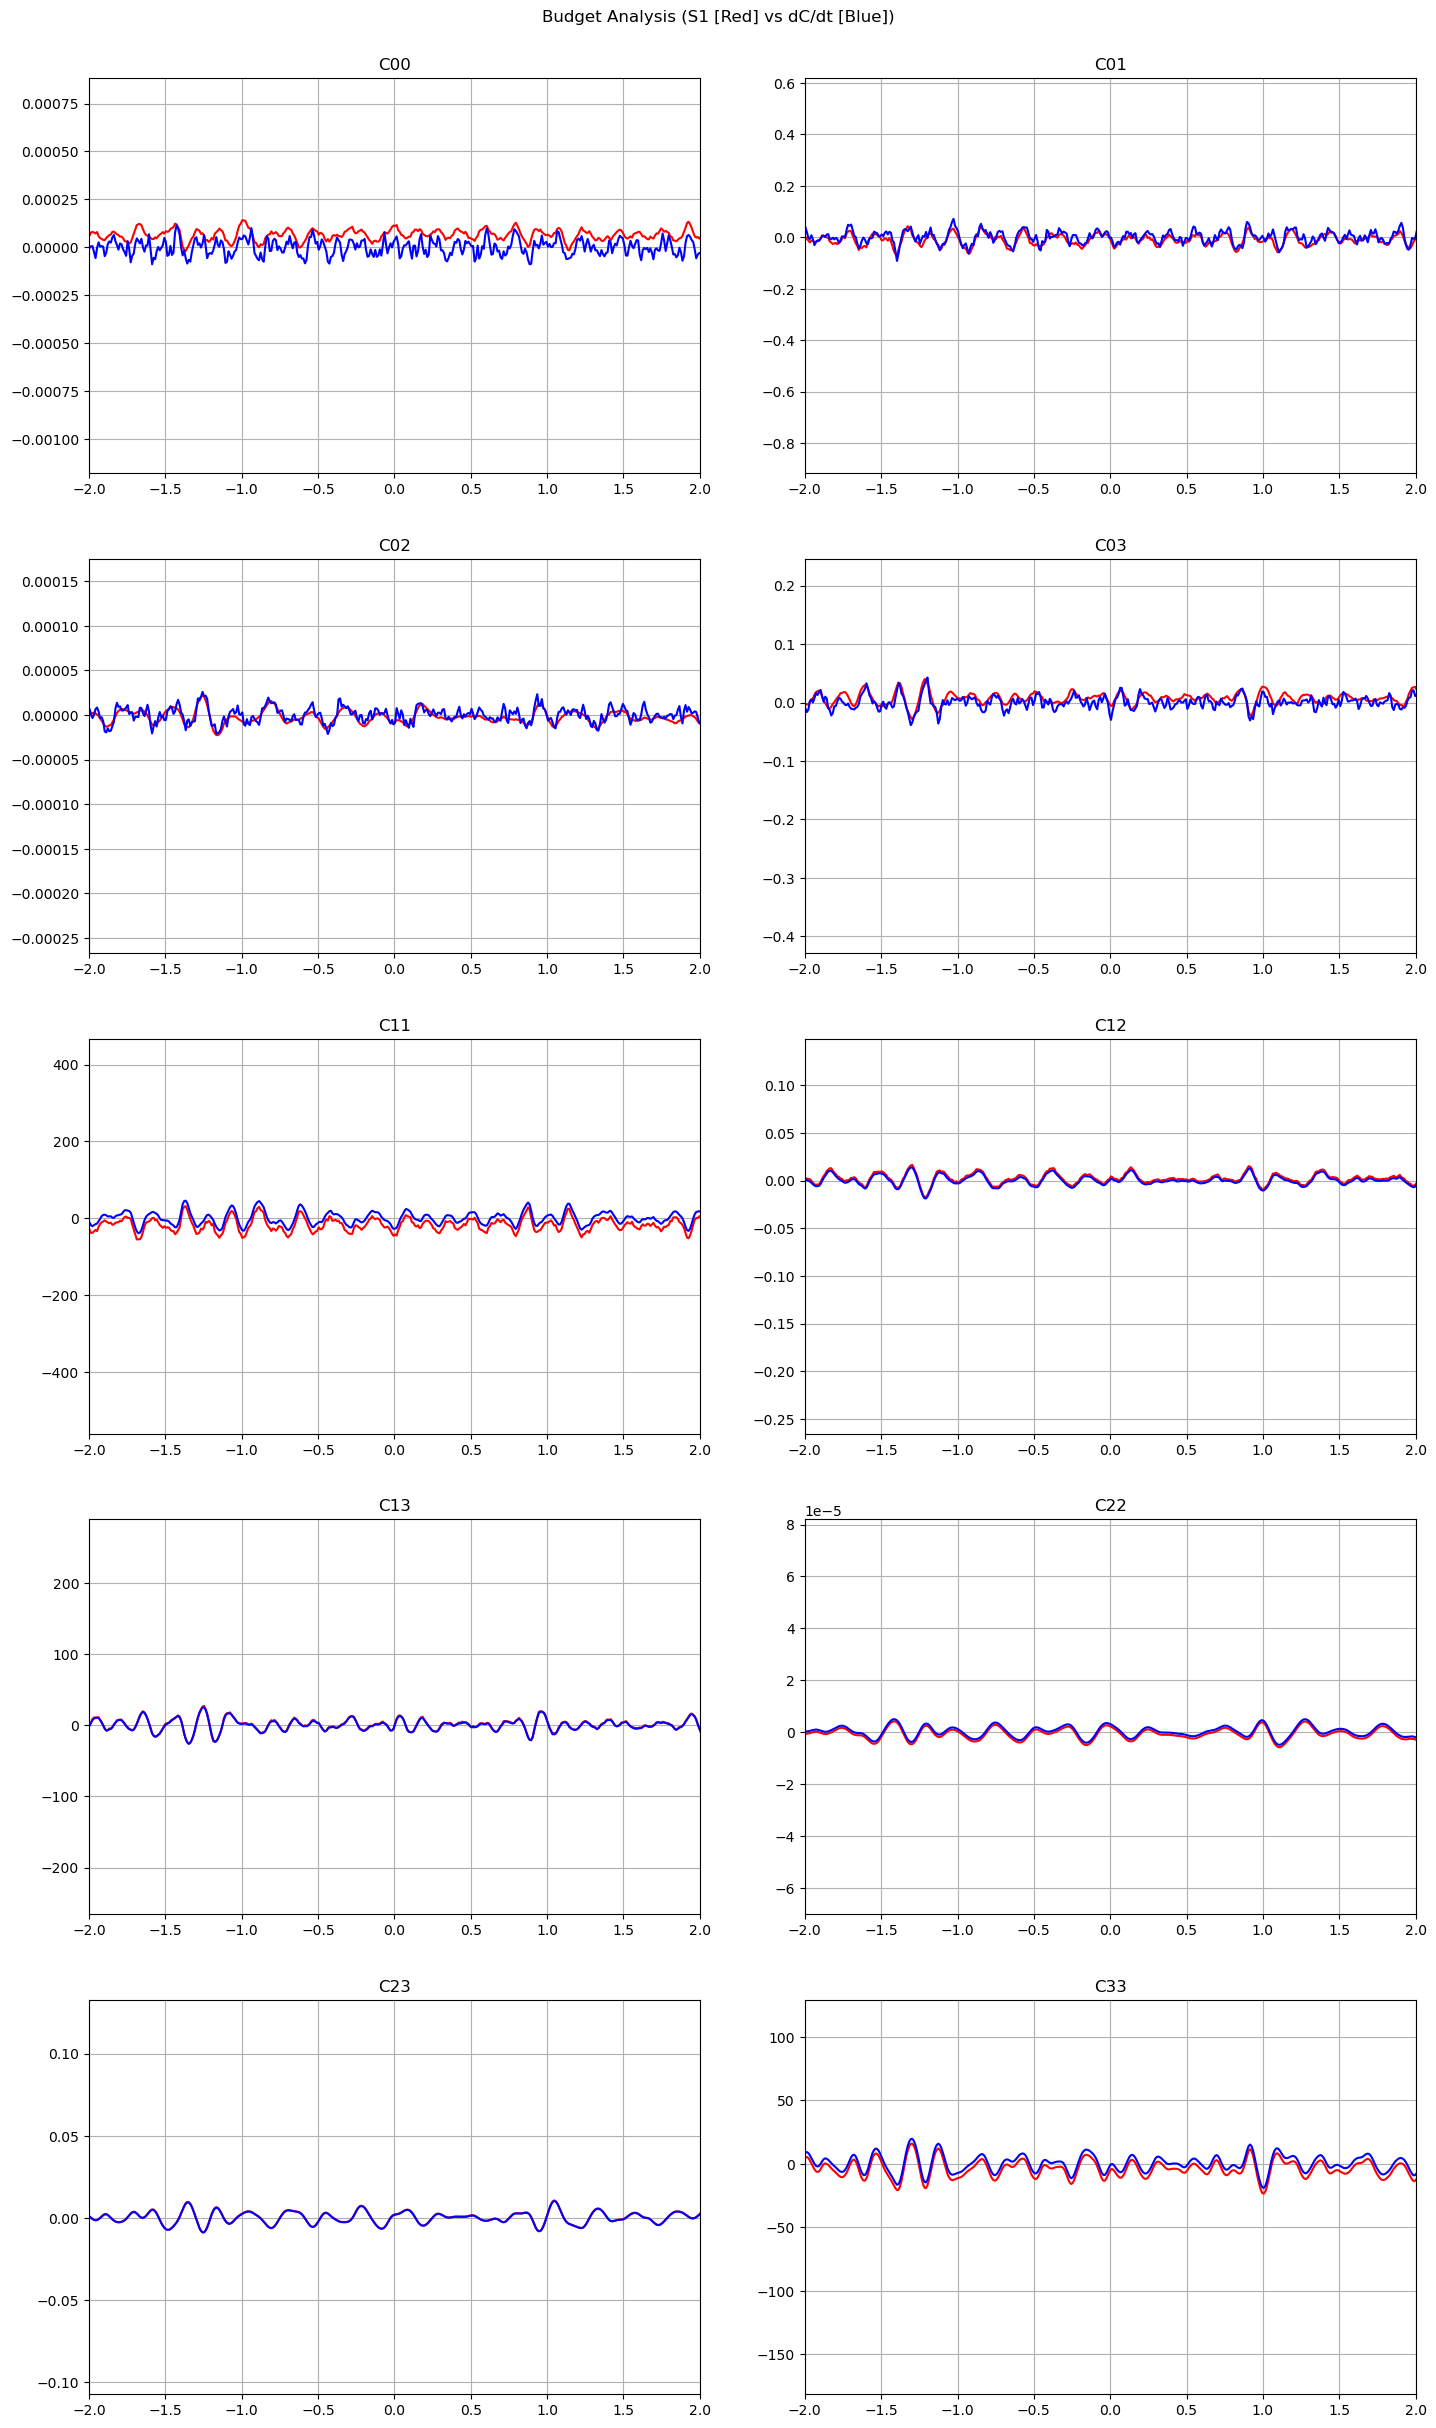

In [ ]:
time_array = np.linspace(-5, 5,  int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s1[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s1[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s1[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s1[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s1[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s1[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s1[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s1[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s1[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s1[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S1 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

In [ ]:
#W<C> term
W_C = np.array([bigW @ C for C in average_C_Matrix])
W_C

#<C>W^T
CW_T = np.array([C @ bigW.T for C in average_C_Matrix])
CW_T

U = np.mean(average_U)
U

#<U>L<C>
result_ULC = np.array([U * (bigL @ C) for C in average_C_Matrix])
result_ULC

#<U><C>L^T 
result_UCLT = np.array([U * (C @ bigL.T) for C in average_C_Matrix])
result_UCLT

s2 = W_C + CW_T + result_ULC + result_UCLT + epsilon*bigQ
s2

array([[[ 3.41536541e-04, -7.13200658e-01, -5.25525436e-05,
          6.09937709e-02],
        [-7.13200658e-01, -5.15884977e+02, -2.34171780e-01,
         -1.78421081e+02],
        [-5.25525436e-05, -2.34171780e-01, -5.48334846e-05,
         -3.61184639e-02],
        [ 6.09937709e-02, -1.78421081e+02, -3.61184639e-02,
          3.98195962e+01]],

       [[ 1.13454113e-05, -8.02578838e-01, -1.12728374e-04,
          9.10687568e-02],
        [-8.02578838e-01, -3.33710611e+02, -2.22453642e-01,
         -2.00887190e+02],
        [-1.12728374e-04, -2.22453642e-01, -5.65857238e-05,
         -3.00617097e-02],
        [ 9.10687568e-02, -2.00887190e+02, -3.00617097e-02,
          5.10143093e+01]],

       [[-3.38760793e-04, -8.16240399e-01, -1.66184543e-04,
          1.11585742e-01],
        [-8.16240399e-01, -1.40632513e+02, -2.01835757e-01,
         -2.30184795e+02],
        [-1.66184543e-04, -2.01835757e-01, -5.67918077e-05,
         -2.51905348e-02],
        [ 1.11585742e-01, -2.30184795e+

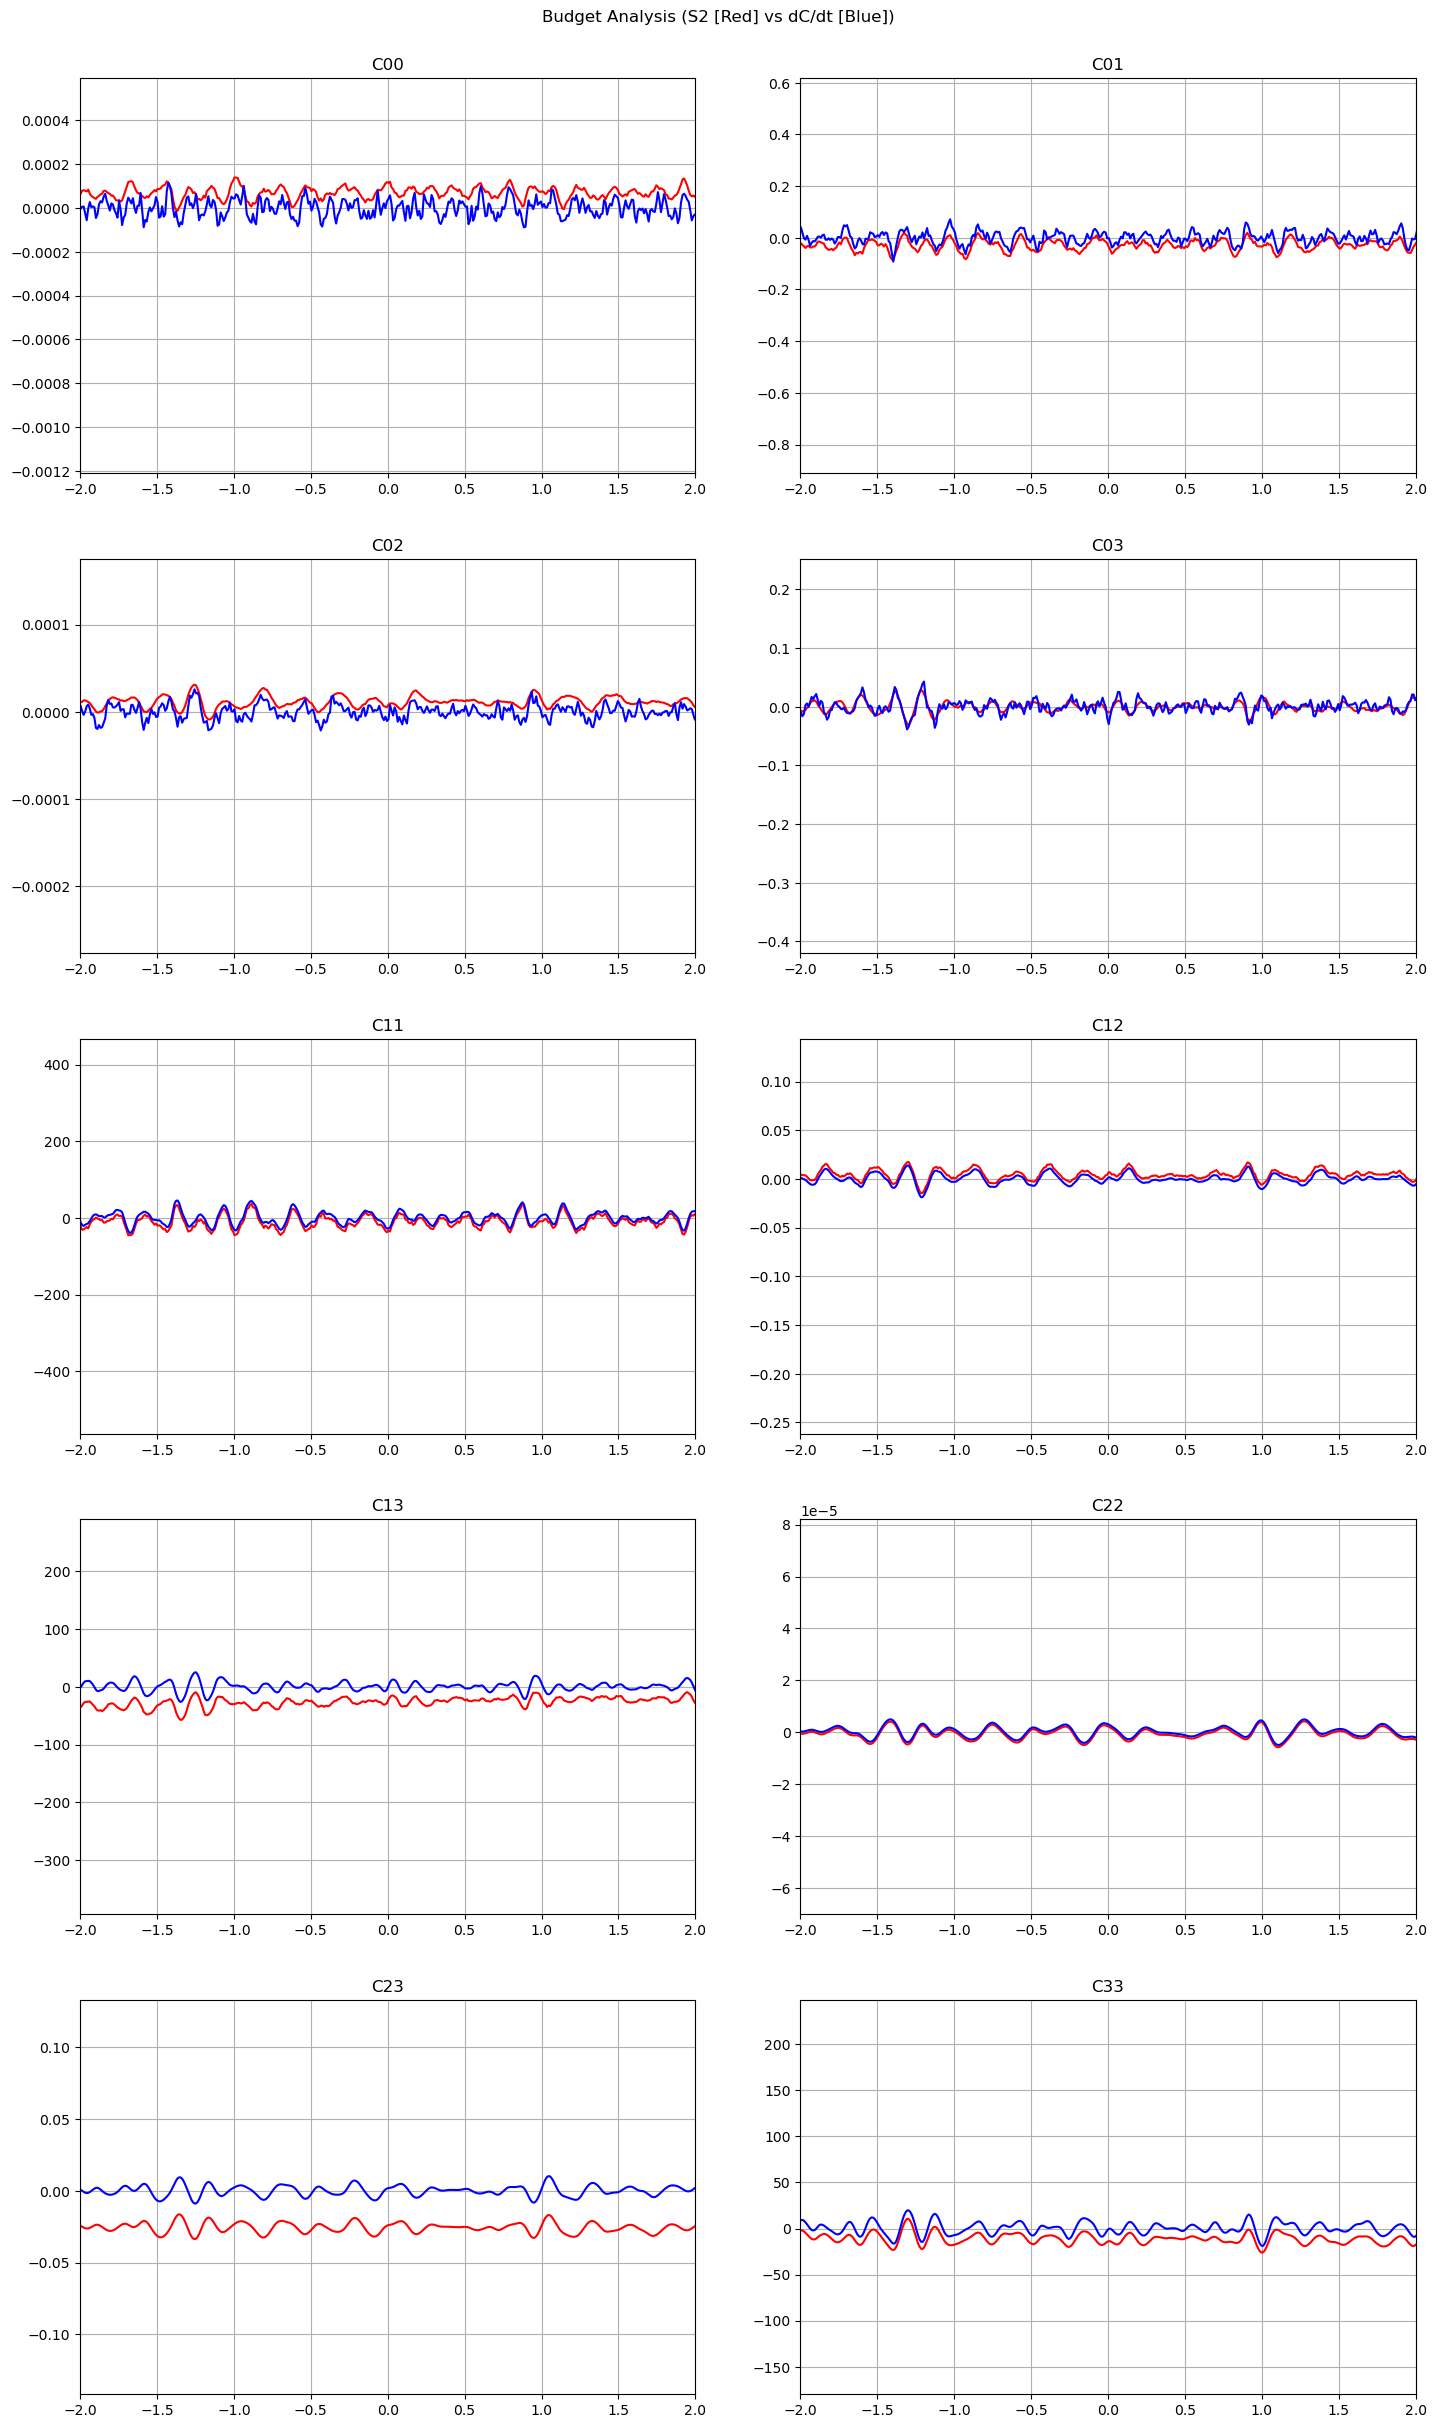

In [ ]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(5, 2, figsize=(15, 25))


axs[0, 0].plot(time_array, s2[:, 0, 0],'r')
axs[0, 0].plot(time_array, dC_dt[:, 0, 0],'b')
axs[0, 0].set_title(f'C00')
axs[0, 0].set_xlim(x_limit)
axs[0, 0].grid()

axs[0, 1].plot(time_array, s2[:, 0, 1],'r')
axs[0, 1].plot(time_array, dC_dt[:, 0, 1],'b')
axs[0, 1].set_title(f'C01')
axs[0, 1].set_xlim(x_limit)
axs[0, 1].grid()

axs[1, 0].plot(time_array, s2[:, 0, 2],'r')
axs[1, 0].plot(time_array, dC_dt[:, 0, 2],'b')
axs[1, 0].set_title(f'C02')
axs[1, 0].set_xlim(x_limit)
axs[1, 0].grid()

axs[1, 1].plot(time_array, s2[:, 0, 3],'r')
axs[1, 1].plot(time_array, dC_dt[:, 0, 3],'b')
axs[1, 1].set_title(f'C03')
axs[1, 1].set_xlim(x_limit)
axs[1, 1].grid()

axs[2, 0].plot(time_array, s2[:, 1, 1],'r')
axs[2, 0].plot(time_array, dC_dt[:, 1, 1],'b')
axs[2, 0].set_title(f'C11')
axs[2, 0].set_xlim(x_limit)
axs[2, 0].grid()

axs[2, 1].plot(time_array, s2[:, 1, 2],'r')
axs[2, 1].plot(time_array, dC_dt[:, 1, 2],'b')
axs[2, 1].set_title(f'C12')
axs[2, 1].set_xlim(x_limit)
axs[2, 1].grid()

axs[3, 0].plot(time_array, s2[:, 1, 3],'r')
axs[3, 0].plot(time_array, dC_dt[:, 1, 3],'b')
axs[3, 0].set_title(f'C13')
axs[3, 0].set_xlim(x_limit)
axs[3, 0].grid()

axs[3, 1].plot(time_array, s2[:, 2, 2],'r')
axs[3, 1].plot(time_array, dC_dt[:, 2, 2],'b')
axs[3, 1].set_title(f'C22')
axs[3, 1].set_xlim(x_limit)
axs[3, 1].grid()

axs[4, 0].plot(time_array, s2[:, 2, 3],'r')
axs[4, 0].plot(time_array, dC_dt[:, 2, 3],'b')
axs[4, 0].set_title(f'C23')
axs[4, 0].set_xlim(x_limit)
axs[4, 0].grid()

axs[4, 1].plot(time_array, s2[:, 3, 3],'r')
axs[4, 1].plot(time_array, dC_dt[:, 3, 3],'b')
axs[4, 1].set_title(f'C33')
axs[4, 1].set_xlim(x_limit)
axs[4, 1].grid()


plt.suptitle(f"Budget Analysis (S2 [Red] vs dC/dt [Blue])")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

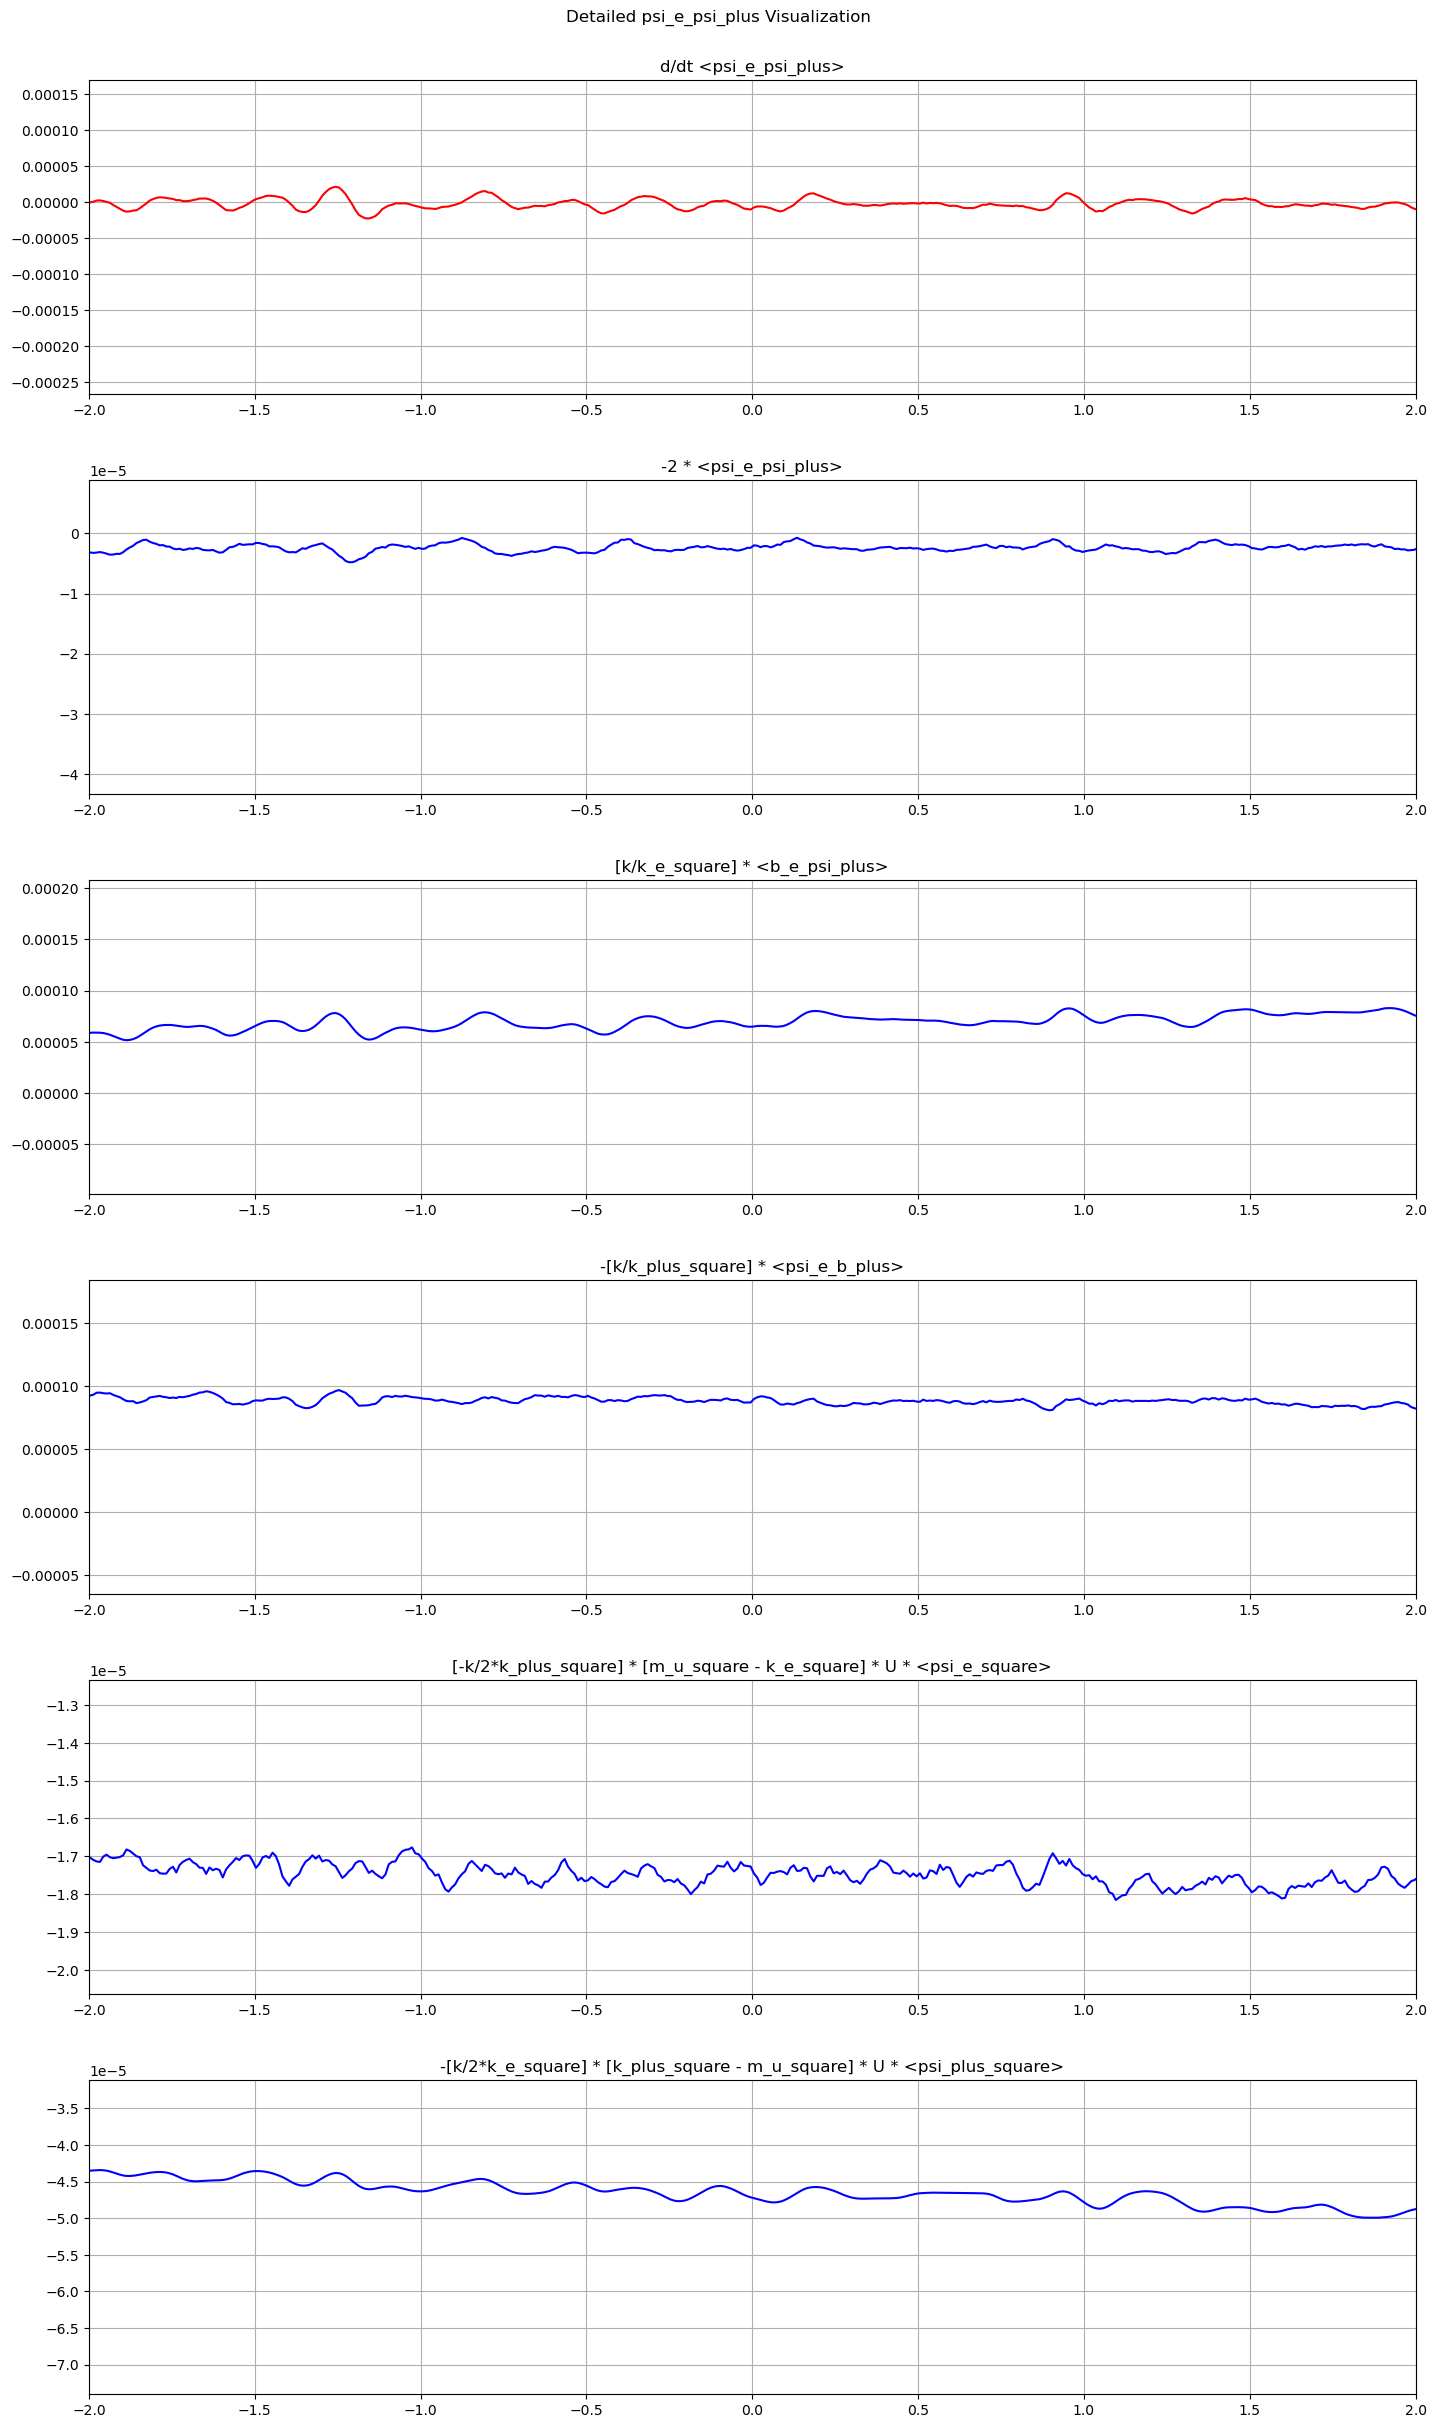

In [ ]:
time_array = np.linspace(-5, 5, int(10/.01))
# time_array = np.arange(2000/10, 2000/10) * dt * 10
#fig, axs = plt.subplots(1,1, figsize = (8, 12))
x_limit = (-2, 2)

fig, axs = plt.subplots(6, 1, figsize=(15, 25))


axs[0].plot(time_array, s1[:, 0, 2],'r')
axs[0].set_title(f'd/dt <psi_e_psi_plus>')
axs[0].set_xlim(x_limit)
axs[0].grid()

axs[1].plot(time_array, -2 * average_R/(0.25 * k * (k_plus_square - k_e_square)),'b')
axs[1].set_title(f'-2 * <psi_e_psi_plus>')
axs[1].set_xlim(x_limit)
axs[1].grid()

axs[2].plot(time_array, (k/k_e_square) * average_b_e_psi_plus_list,'b')
axs[2].set_title(f'[k/k_e_square] * <b_e_psi_plus>')
axs[2].set_xlim(x_limit)
axs[2].grid()

axs[3].plot(time_array, (-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list,'b')
axs[3].set_title(f'-[k/k_plus_square] * <psi_e_b_plus>')
axs[3].set_xlim(x_limit)
axs[3].grid()

axs[4].plot(time_array, (-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e),'b')
axs[4].set_title(f'[-k/2*k_plus_square] * [m_u_square - k_e_square] * U * <psi_e_square>')
axs[4].set_xlim(x_limit) 
axs[4].grid()

axs[5].plot(time_array, (-k/(2*k_plus_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus),'b')
axs[5].set_title(f'-[k/2*k_e_square] * [k_plus_square - m_u_square] * U * <psi_plus_square>')
axs[5].set_xlim(x_limit)
axs[5].grid()


plt.suptitle(f"Detailed psi_e_psi_plus Visualization")



#plt.subplots_adjust(wspace=.4)
#plt.subplots_adjust(hspace=.4)
plt.tight_layout(pad = 3)
plt.show()

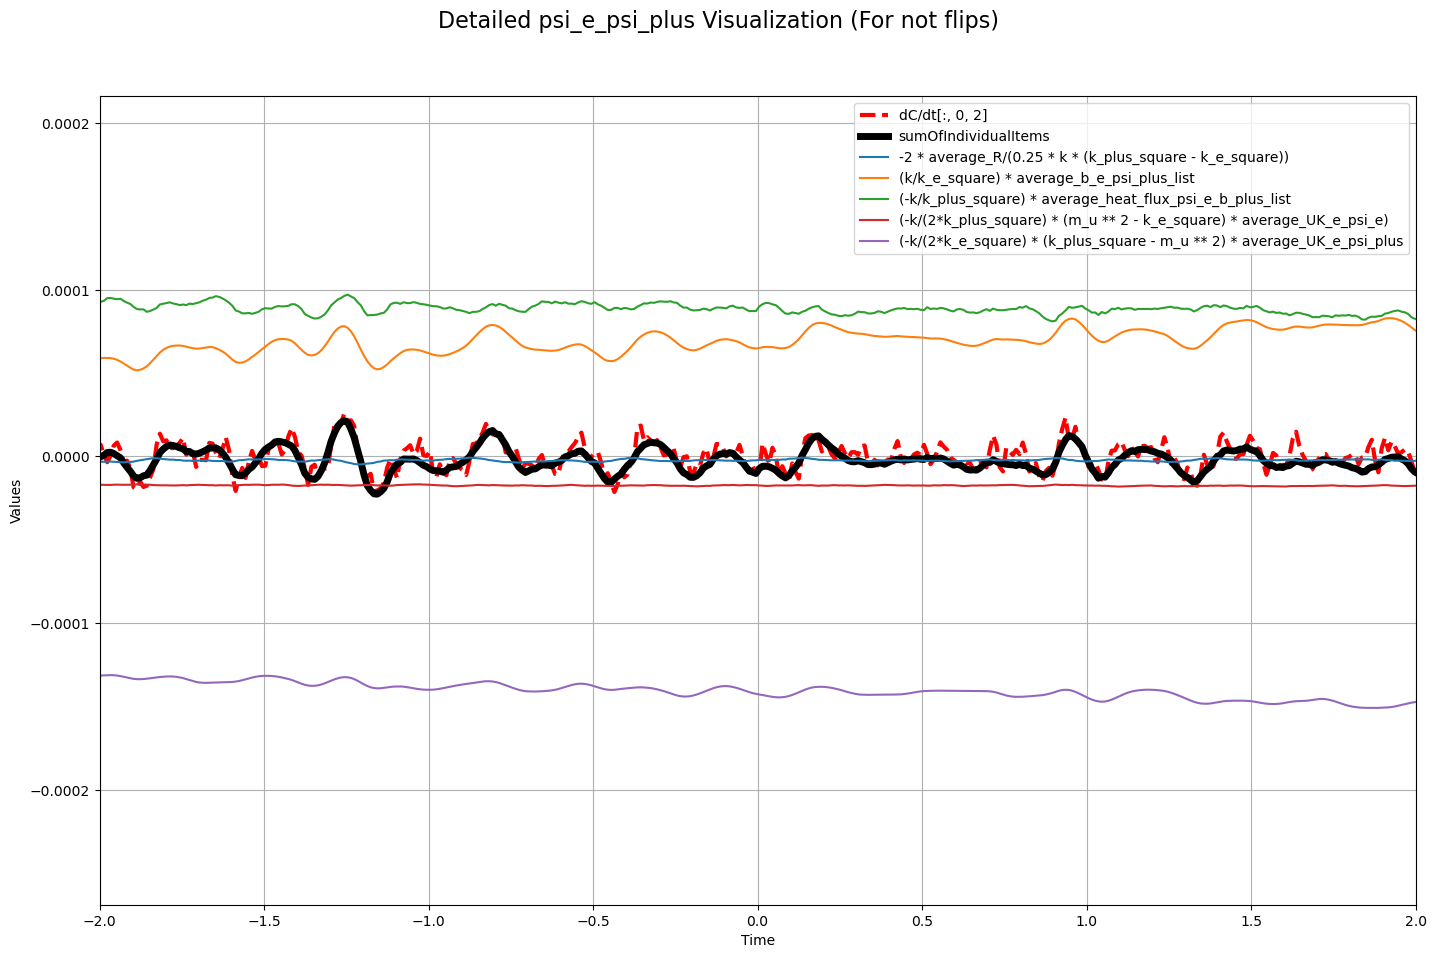

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = (-2 * average_R / (0.25 * k * (k_plus_square - k_e_square))) + \
                       ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) + \
                       ((-k / (2 * k_plus_square) * (np.square(m_u) - k_e_square) * average_UK_e_psi_e)) + \
                       ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# ax.plot(time_array, average_R/1000, '-b', lw = 3)
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Detailed psi_e_psi_plus Visualization (For not flips)", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

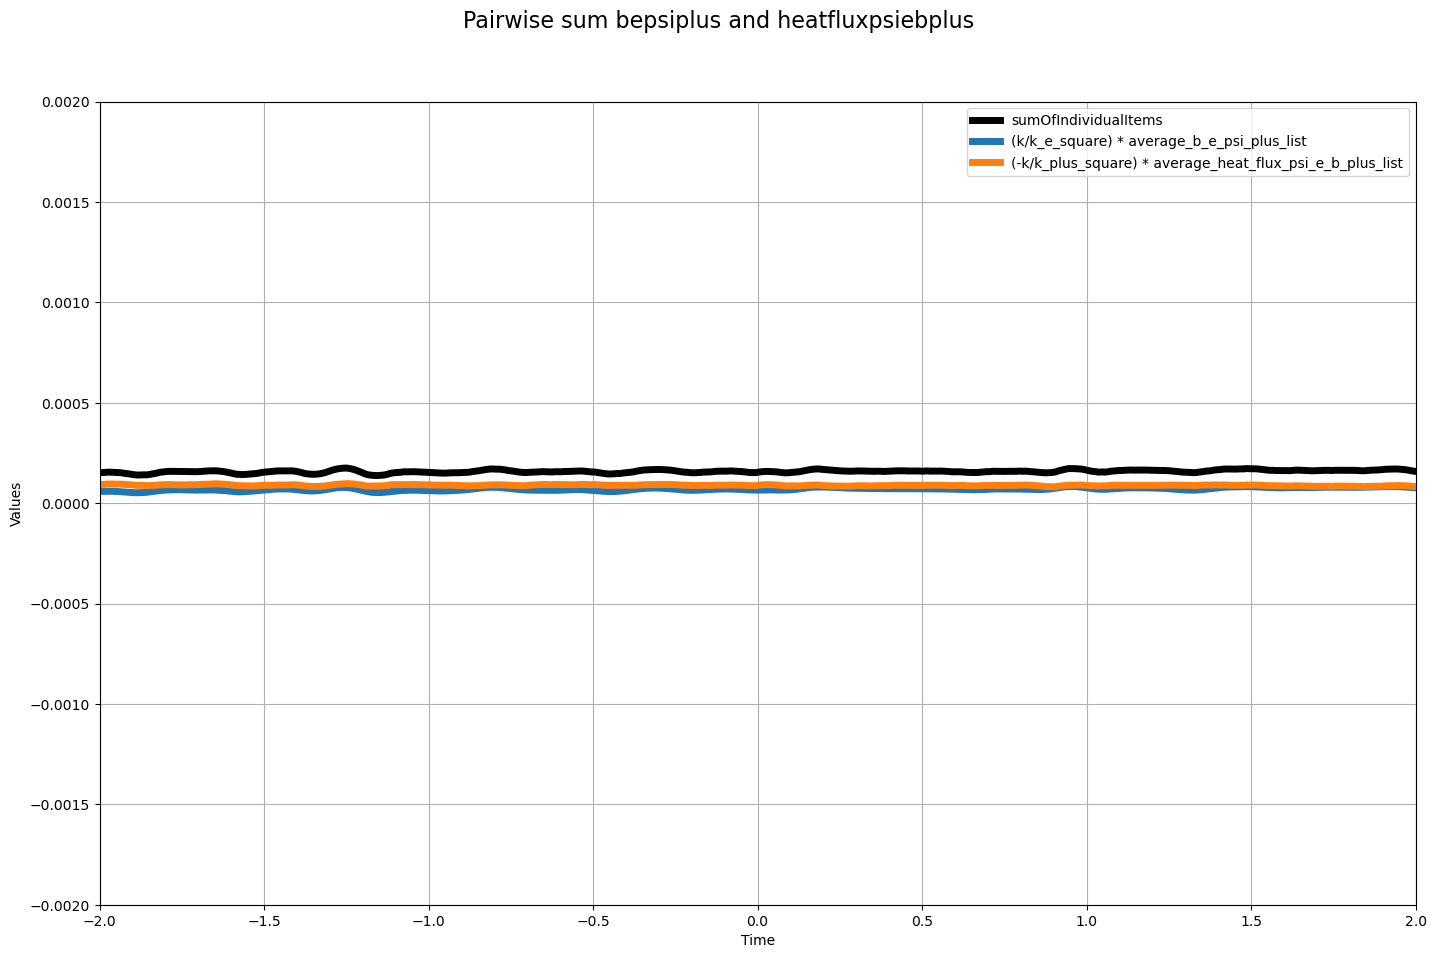

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = ((k / k_e_square) * average_b_e_psi_plus_list) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list) 
                        # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3], lw = 5)
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4], lw = 5)
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Pairwise sum bepsiplus and heatfluxpsiebplus", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

#Sum of the 2 heat flux terms

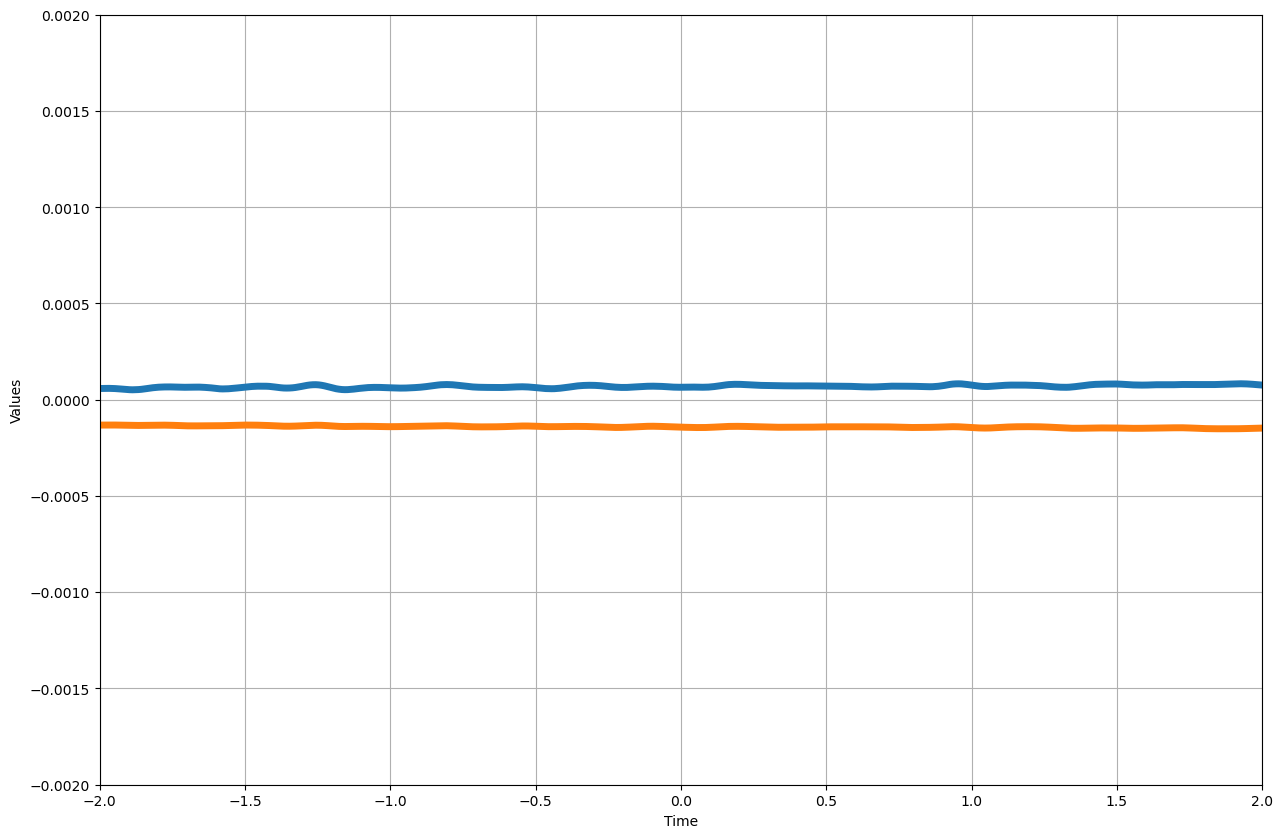

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',labels[2],
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

ax.plot(time_array, ((k / k_e_square) * average_b_e_psi_plus_list),label=labels[3], lw = 5)
ax.plot(time_array, (-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus),label=labels[6], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
# ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4])
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
# ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6])


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")
labels[2]
plt.show()

#Sum of the b_e_psi_plus + kinetic energy of exicted wave

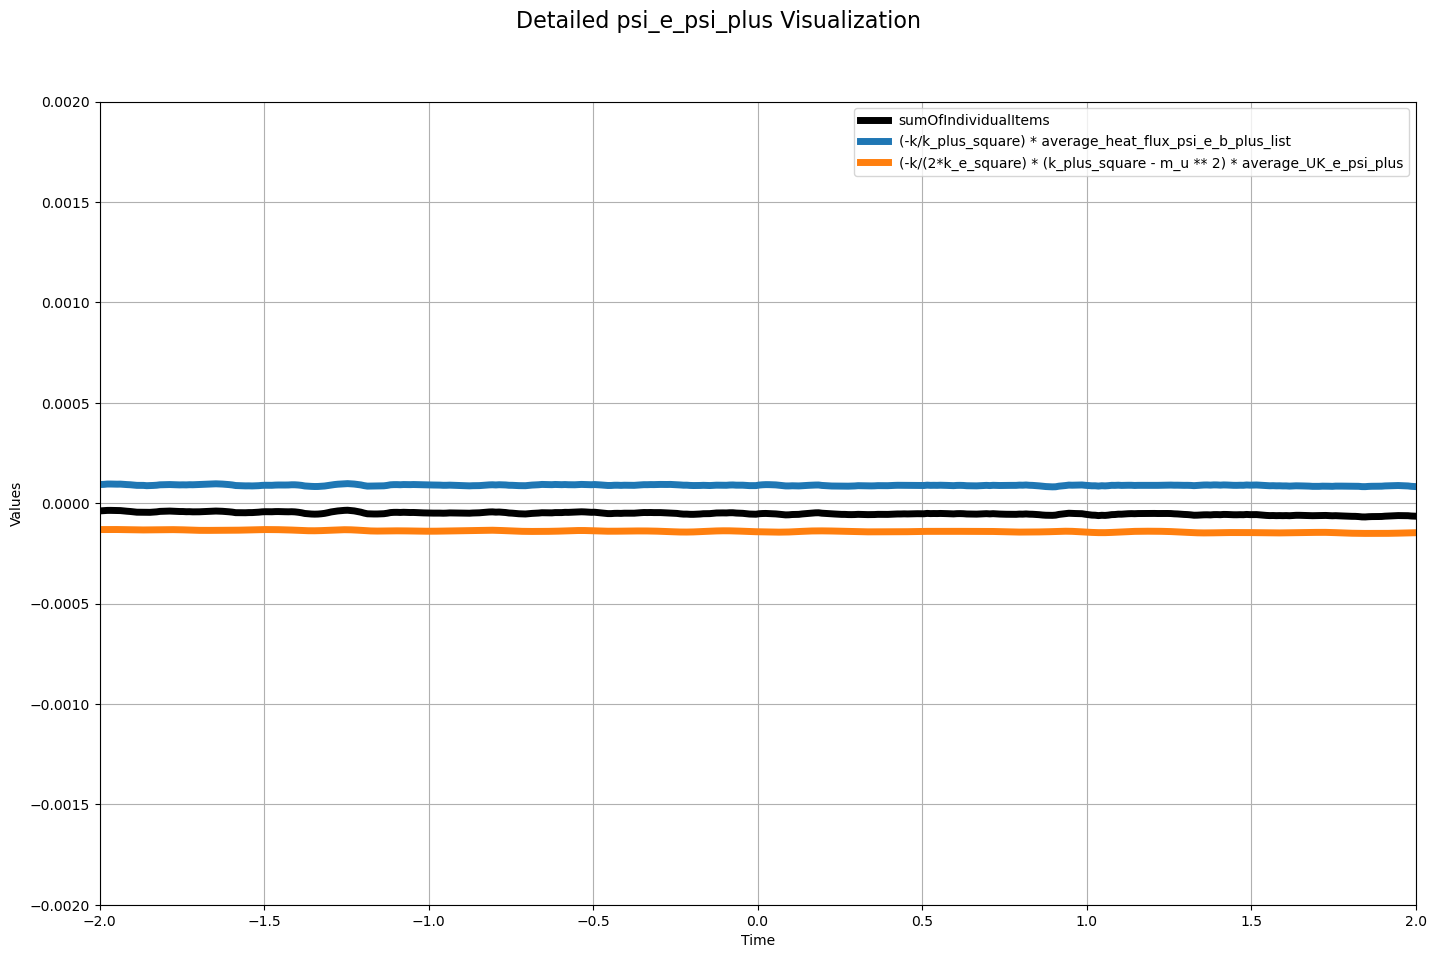

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

labels = [
    'dC/dt[:, 0, 2]',
    'sumOfIndividualItems',
    '-2 * average_R/(0.25 * k * (k_plus_square - k_e_square))',
    '(k/k_e_square) * average_b_e_psi_plus_list',
    '(-k/k_plus_square) * average_heat_flux_psi_e_b_plus_list',
    '(-k/(2*k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e)',
    '(-k/(2*k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus'
]

sumOfIndividualItems = -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus) + \
                       ((-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list)
                        # ((-k / (2 * k_e_square) * (k_plus_square - np.square(m_u)) * average_UK_e_psi_plus))

# ax.plot(time_array, dC_dt[:, 0, 2], '--r',label=labels[0], lw = 3)
ax.plot(time_array, sumOfIndividualItems,'-k',label=labels[1], lw = 5)
# ax.plot(time_array, -2 * average_R / (0.25 * k * (k_plus_square - k_e_square)), label=labels[2])
# # ax.plot(time_array, average_R/1000, '-b', lw = 3)
# ax.plot(time_array, (k / k_e_square) * average_b_e_psi_plus_list, label=labels[3])
ax.plot(time_array, (-k / k_plus_square) * average_heat_flux_psi_e_b_plus_list, label=labels[4], lw = 5)
# ax.plot(time_array, -(k / (2 * k_plus_square) * (m_u ** 2 - k_e_square) * average_UK_e_psi_e), label=labels[5])
ax.plot(time_array, -(k / (2 * k_e_square) * (k_plus_square - m_u ** 2) * average_UK_e_psi_plus), label=labels[6], lw = 5)


ax.set_xlim(x_limit)
ax.set_ylim((-.002, .002))
ax.grid(True)
ax.set_xlabel("Time")
ax.set_ylabel("Values")

ax.legend(loc='best')

plt.suptitle(f"Detailed psi_e_psi_plus Visualization", fontsize=16)

plt.tight_layout(pad=3)
plt.show()

#Sum of kepsi plus and psiebplus

In [ ]:
def std_across_axis(arrays):
    """
    Calculate the standard deviation across axis 1 for a list or array of 2D numpy arrays.
    Returns a single array of standard deviations for each array in the input.
    
    Parameters:
        arrays (array-like): List or array of shape (N, M) or (N, M, ...) where N is the number of arrays.
        
    Returns:
        np.ndarray: Array of standard deviations, shape (N,).
    """
    # arrays = np.asarray(arrays)
    return np.std(arrays, axis=0)

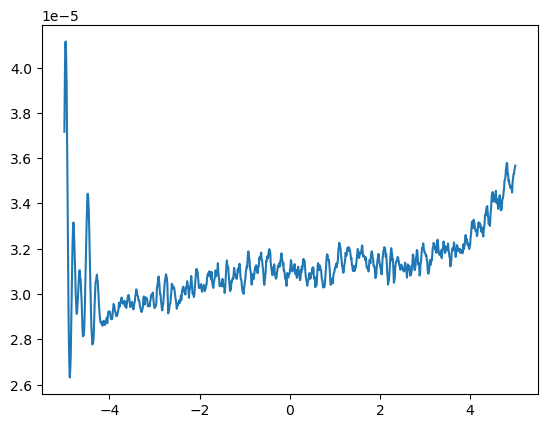

In [ ]:
plt.plot(time_array, average_U * average_k_e_psi_e_list)

In [ ]:
U_k_e_psi_e = np.array([
    np.array(u) * np.array(k)
    for u, k in zip(df['u_list'], df['k_e_psi_e_list'])
])

U_k_e_psi_e_stdev = std_across_axis(U_k_e_psi_e)

In [ ]:
U_k_e_psi_e_average = average_arrays(*list(U_k_e_psi_e))

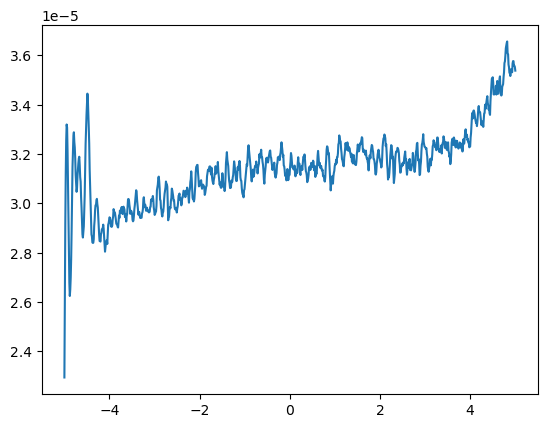

In [ ]:
plt.plot(time_array, U_k_e_psi_e_average)

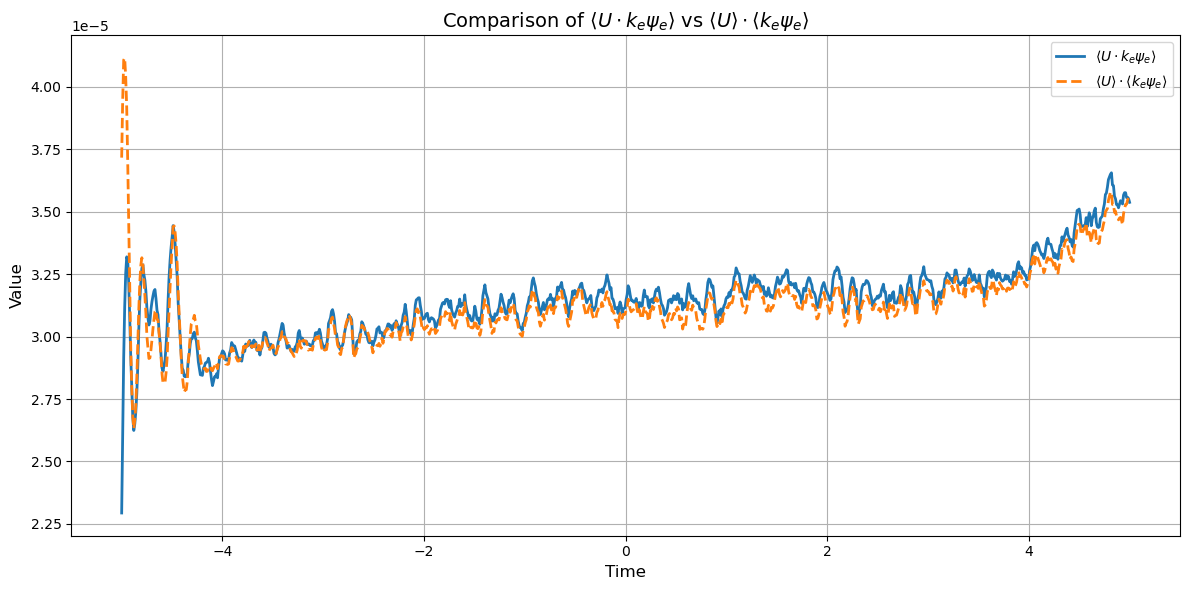

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, average_U * average_k_e_psi_e_list, 
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='--', linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()


#### Bootstrapping


In [ ]:
len(average_U)

1000

In [ ]:
avg_U_1 = df['u_list'].iloc[:len(df['u_list'])//2]
avg_U_1 = average_arrays(*list(avg_U_1))
avg_U_2 = df['u_list'].iloc[len(df['u_list'])//2:]
avg_U_2 = average_arrays(*list(avg_U_2))

average_k_e_psi_e_list_1 = df['k_e_psi_e_list'].iloc[len(df['k_e_psi_e_list'])//2:]
average_k_e_psi_e_list_1 = average_arrays(*average_k_e_psi_e_list_1)
average_k_e_psi_e_list_2 = df['k_e_psi_e_list'].iloc[:len(df['k_e_psi_e_list'])//2]
average_k_e_psi_e_list_2 = average_arrays(*average_k_e_psi_e_list_2)


U_k_e_psi_e_1 = np.array([
    np.array(u) * np.array(k)
    for u, k in zip(df['u_list'].iloc[:len(df['u_list'])//2], df['k_e_psi_e_list'].iloc[:len(df['u_list'])//2])
])

U_k_e_psi_e_2 = np.array([
    np.array(u) * np.array(k)
    for u, k in zip(df['u_list'].iloc[len(df['u_list'])//2:], df['k_e_psi_e_list'].iloc[len(df['u_list'])//2:])
])

U_k_e_psi_e_average_1 = average_arrays(*list(U_k_e_psi_e_1))
U_k_e_psi_e_average_2 = average_arrays(*list(U_k_e_psi_e_2))

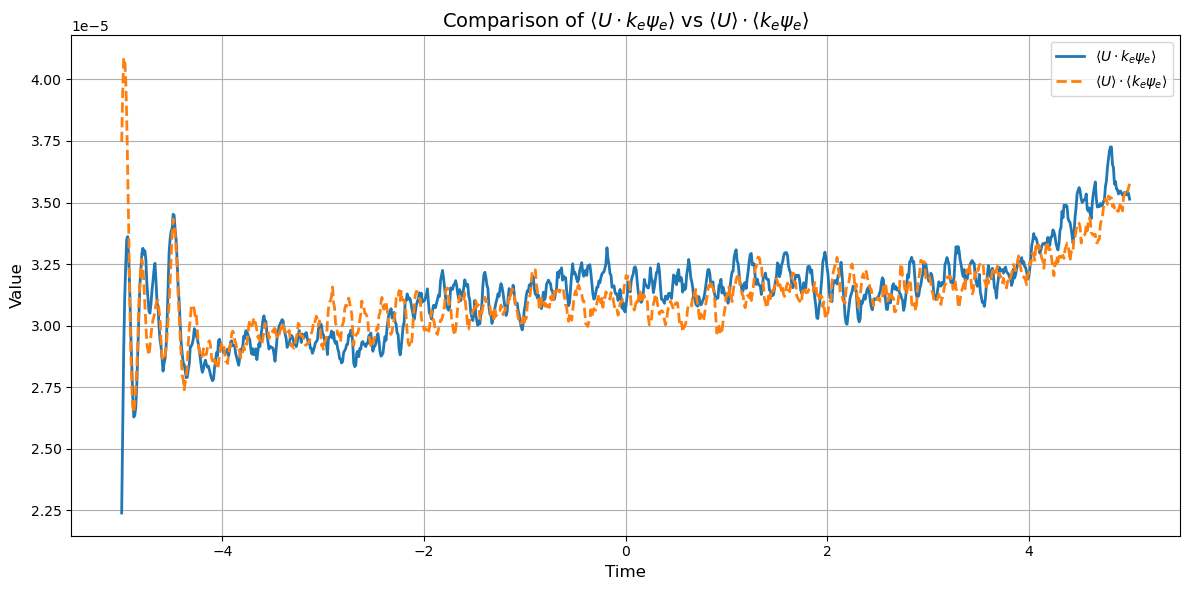

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_array, U_k_e_psi_e_average_1, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, avg_U_1 * average_k_e_psi_e_list_1, 
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='--', linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()

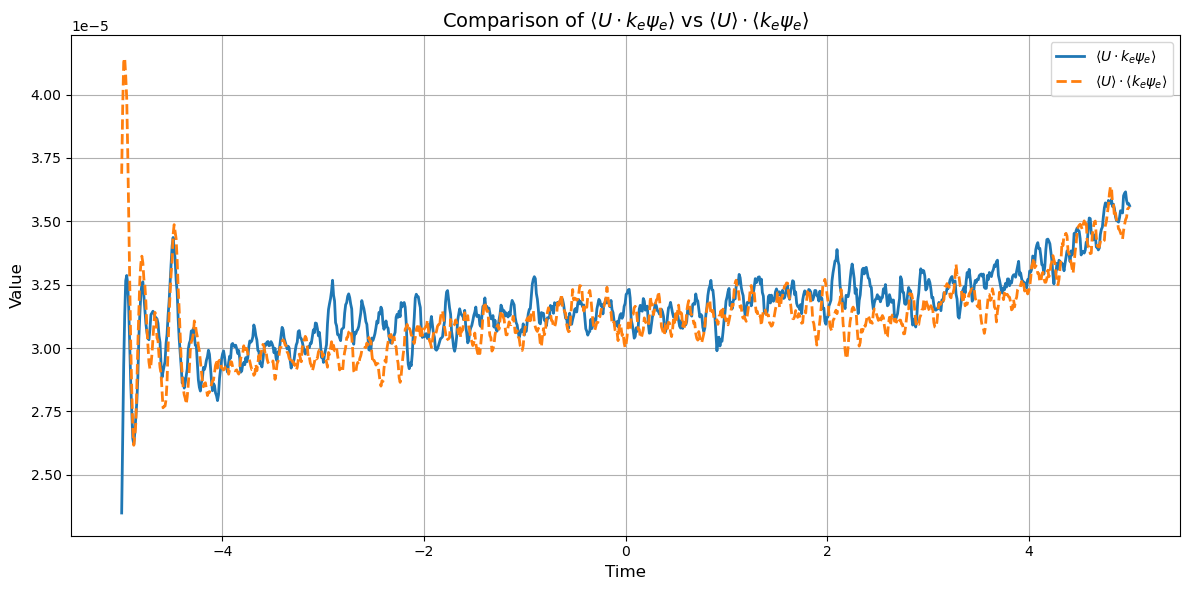

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_array, U_k_e_psi_e_average_2, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, avg_U_2 * average_k_e_psi_e_list_2, 
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='--', linewidth=2)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
standard_error_diff= np.std(U_k_e_psi_e_average-(average_U * average_k_e_psi_e_list), axis=0) / np.sqrt(1000)

In [ ]:
standard_error_diff

2.9483065771715655e-08

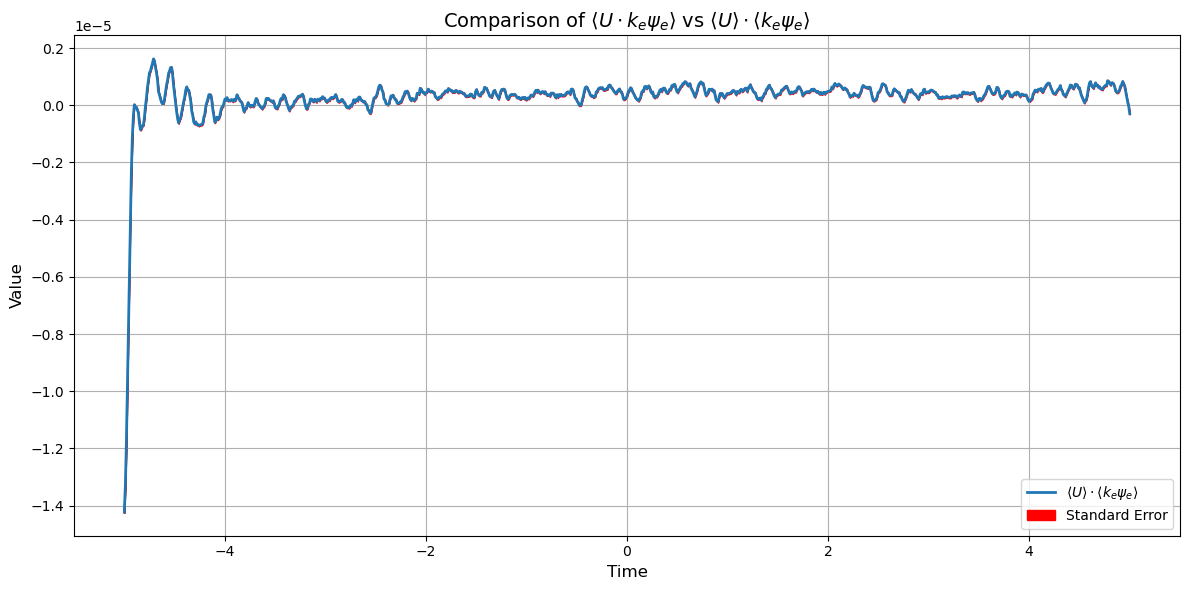

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
calc_array = U_k_e_psi_e_average-(average_U * average_k_e_psi_e_list)
# ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, calc_array,
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='-', linewidth=2)

ax.fill_between(time_array, 
                calc_array - standard_error_diff, 
                calc_array + standard_error_diff, 
                alpha=1, label='Standard Error',color='red')

# ax.errorbar(time_array, 
#             U_k_e_psi_e_average - (average_U * average_k_e_psi_e_list), 
#             yerr=standard_error_diff, 
#             label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', 
#             linestyle='--', 
#             linewidth=2, 
#             capsize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()


#### Temporal Calculations

In [ ]:
def std_across_axis(arrays):
    return np.std(arrays, axis=0)

In [ ]:
U_k_e_psi_e_stdev = std_across_axis(U_k_e_psi_e)

In [ ]:
U_k_e_psi_e_stdev.shape

(1000,)

In [ ]:
U_k_e_psi_e_stError = U_k_e_psi_e_stdev/100

In [ ]:
U_k_e_psi_e.shape

(10000, 1000)

In [ ]:
U_k_e_psi_e_average = average_arrays(*list(U_k_e_psi_e))

In [ ]:
U_k_e_psi_e_average.shape

(1000,)

In [ ]:
average_U_Ke_psi_e = average_U * average_k_e_psi_e_list
average_U_Ke_psi_e.shape

(1000,)

In [ ]:
std_U = np.std(df['u_list'].tolist(), axis=0)
std_K_e_psi_e = np.std(df['k_e_psi_e_list'].tolist(), axis=0)
std_U.shape, std_K_e_psi_e.shape

((1000,), (1000,))

In [ ]:
std_err_U = std_U / 100
std_err_k_e_psi_e = std_K_e_psi_e / 100

In [ ]:
st_err_U_K_e_psi_e = average_U * average_k_e_psi_e_list * np.sqrt((std_err_U / average_U) ** 2 + (std_err_k_e_psi_e / average_k_e_psi_e_list) ** 2)
st_err_U_K_e_psi_e.shape

(1000,)

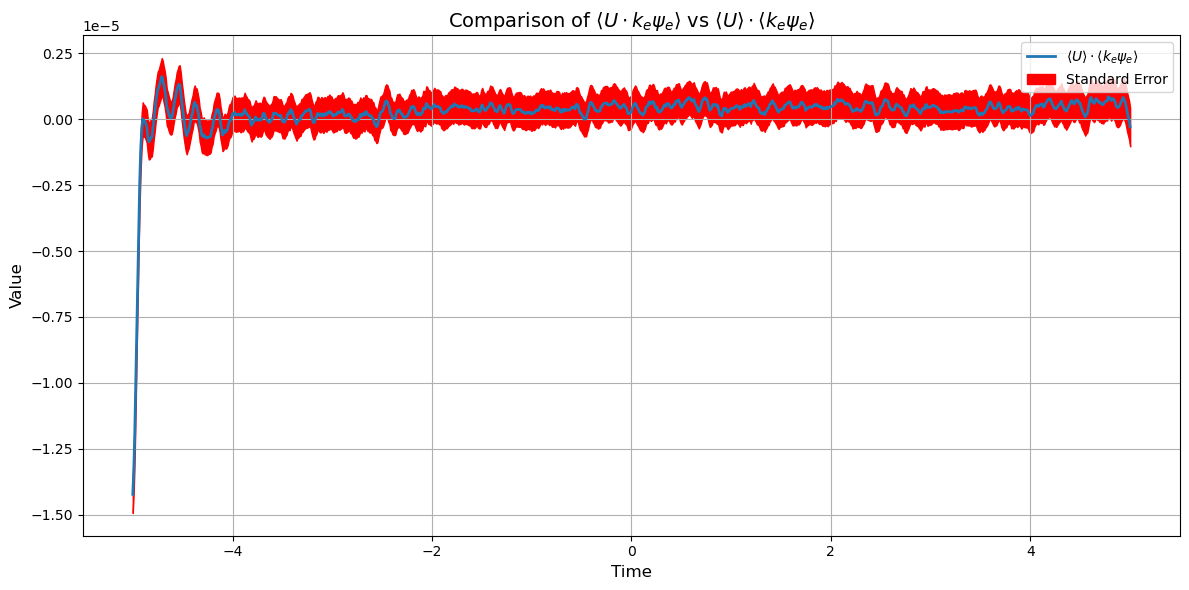

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
standard_error_diff = np.sqrt(st_err_U_K_e_psi_e ** 2 + U_k_e_psi_e_stError ** 2)
calc_array = U_k_e_psi_e_average - average_U_Ke_psi_e
# ax.plot(time_array, U_k_e_psi_e_average, label=r'$\langle U \cdot k_{e}\psi_{e} \rangle$', linewidth=2)
ax.plot(time_array, calc_array,
        label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', linestyle='-', linewidth=2)

ax.fill_between(time_array, 
                calc_array - standard_error_diff, 
                calc_array + standard_error_diff, 
                alpha=1, label='Standard Error',color='red')

# ax.errorbar(time_array, 
#             U_k_e_psi_e_average - (average_U * average_k_e_psi_e_list), 
#             yerr=standard_error_diff, 
#             label=r'$\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', 
#             linestyle='--', 
#             linewidth=2, 
#             capsize=3)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title(r'Comparison of $\langle U \cdot k_{e}\psi_{e} \rangle$ vs $\langle U \rangle \cdot \langle k_{e}\psi_{e} \rangle$', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()
